In [1]:
import pandas as pd
import numpy as np
import geopy.distance
import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import statsmodels.api as sm
import pingouin as pg

from scipy.stats import linregress
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")



In [2]:
# 1. Preprocess data - Merge all dataset
warnings.filterwarnings("ignore", category=FutureWarning) # Ignore warnings

airline_df = pd.read_excel('data/AirportPassengers.xlsx') # passengers count
visitors_df = pd.read_excel('data/InternationalVisitors.xlsx')
# House Price - ALL cities 
zillow_df = pd.read_csv('data/Zillow_Value_AllCities.csv')  # https://www.zillow.com/research/data/ 

#Population
bos_pop_df = pd.read_csv("data/BOS_population.csv") # https://data.boston.gov/dataset/2020-census-for-boston/resource/5800a0a2-6acd-41a3-9fe0-1bf7b038750d
den_pop_df = pd.read_csv("data/DEN_population.csv") # https://catalog.data.gov/dataset/2010-census-populations-by-zip-code
lax_pop_df = pd.read_csv("data/LAX_population.csv") # https://data.lacounty.gov/datasets/lacounty::2020-census-blocks/about?layer=3
nyc_pop_df = pd.read_csv("data/NYC_population.csv") # https://catalog.data.gov/dataset/new-york-city-population-by-neighborhood-tabulation-areas



#Rename columns for population data for neighbourhood
bos_pop_df = bos_pop_df.rename(columns={"tract20_nbhd": "neighbourhood", "P0020001": "population" })
den_pop_df = den_pop_df.rename(columns={"NAME": "neighbourhood", "SUM_POPULATION_2010": "population" })
nyc_pop_df = nyc_pop_df.rename(columns={"NTA Name": "neighbourhood", "Population": "population" })
lax_pop_df = lax_pop_df.rename(columns={"COMM": "neighbourhood", "POP20": "population" })

#Rename column for airport arrival passengers and international visitors
airline_df = airline_df.rename(columns={"DEST": "airport_code", "PASSENGERS": "passengers" })
visitors_df = visitors_df.rename(columns={"U.S. MSAs Visited": "city", "Expanded Estimates": "visitors" })

# Airbnb Listing for Short and Long Term Rental https://insideairbnb.com/get-the-data/
bos_df = pd.read_csv("data/BOS_Listings.csv")
den_df = pd.read_csv("data/DEN_Listings.csv")
lax_df = pd.read_csv("data/LAX_Listings.csv")
nyc_df = pd.read_csv("data/NYC_Listings.csv")



In [3]:
# 2. Prepare data for house prices from zillow dataframe
house_price_df = zillow_df
columns = ['RegionName',
           'State', 'City']
date_columns = [col for col in house_price_df.columns if col not in columns]

# Reshape from wide to long format
house_price_df = pd.melt(
    house_price_df,
    id_vars=columns,
    value_vars=date_columns,
    var_name='Date',
    value_name='house_value'
)

house_price_df['Date'] = pd.to_datetime(house_price_df['Date'], errors='coerce', infer_datetime_format=True)
house_price_df = house_price_df.dropna(subset=['Date'])
most_recent_date = house_price_df['Date'].max()
house_price_df = house_price_df[house_price_df['Date'] == most_recent_date]
#house_price_df['house_value'] = house_price_df['house_value'].apply(lambda x: f"{x:,.2f}")
house_price_df['house_value'] = house_price_df['house_value'].fillna(0)
#house_price_df = house_price_df[house_price_df["RegionName"] == "East Colfax"]
#house_price_df = house_price_df.drop(columns=columns)
print(house_price_df.head())



                RegionName State         City       Date   house_value
7343440           Maryvale    AZ      Phoenix 2025-02-28  3.376712e+05
7343441           Paradise    NV    Las Vegas 2025-02-28  4.407130e+05
7343442    Upper West Side    NY     New York 2025-02-28  2.954627e+06
7343443    Upper East Side    NY     New York 2025-02-28  4.636830e+06
7343444  South Los Angeles    CA  Los Angeles 2025-02-28  6.947944e+05


In [4]:
# 3 Define function to clean and filter data 
def add_city(listing_df, pop_df, pass_vol_df, visitors_df, airport_city, airport_code, airport_coords):
    air_location = tuple(airport_coords)
    df  = listing_df
   
    # Step 1: Clean and filter listings
    long_stay_threshold = 14 
    df['long_stay'] = np.where(df['minimum_nights'] > long_stay_threshold, 1, 0)
    df['airport_city'] = airport_city
    df['airport_code'] = airport_code

    # Step 2: Calculate distance from airport
    def calculate_distance(row):
        listing_location = (row['latitude'], row['longitude'])
        return geopy.distance.geodesic(air_location, listing_location).miles
    
    df['distance_from_airport'] = df.apply(calculate_distance, axis=1)

    # Step 3. Merge population data 
    df = df.merge(pop_df[['neighbourhood', 'population']], on='neighbourhood', how='left')

    # Step 4: Process airport and fare data
    pass_vol_df = pass_vol_df[pass_vol_df['airport_code'] == airport_code]
    pass_vol_df = pass_vol_df.groupby('airport_code')['passengers'].sum().reset_index()
    
  # Step 4: Process international visitors data 
    # get city from first column
    visitors_df['city'] = visitors_df['city'].apply(lambda x: x.split('-')[0].strip())
    visitors_df = visitors_df[visitors_df['city'] == airport_city]
    visitors_df = visitors_df.groupby('city')['visitors'].sum().reset_index()
    df = df.merge(pass_vol_df[['airport_code', 'passengers']], on='airport_code',  how='left')
    df = df.merge(visitors_df[['city','visitors']], left_on='airport_city', right_on='city')
    columns_to_drop = [col for col in ['latitude', 'longitude', 'airport_city_x'] if col in df.columns]
    df_listings = df.drop(columns=columns_to_drop)

    # Step 5: Merge with Zillow data
    neighbourhood = df_listings.merge(house_price_df, how='left', left_on=['neighbourhood','airport_city'], right_on=['RegionName','City'])

    # Step 6: Drop columns if they exist
    columns_to_drop = [col for col in ['latitude', 'longitude', 'airport_city_x'] if col in neighbourhood.columns]
    df = neighbourhood.drop(columns=columns_to_drop)

    # Replace NaN and None to 0
    df['population'] = df['population'].fillna(0).astype(int)
    df['house_value'] = df['house_value'].fillna(0)

   # Create long_stay and short_stay as separate binary columns
    df["long_term_stays"] = (df["long_stay"] == 1).astype(int)
    df["short_term_stays"] = (df["long_stay"] == 0).astype(int)

    # Step 7: Group and aggregate
    agg_dict = {
        'price': 'mean',
        'availability_365': 'mean',
        'minimum_nights': 'mean',
        'long_term_stays': 'mean',
        'short_term_stays': 'mean',
        'reviews_per_month': 'mean',
        'number_of_reviews_ltm': ['mean', 'sum'],
        'distance_from_airport': 'mean',
        'population': 'mean',
        'house_value': 'mean',
        'neighbourhood': 'count',
        'passengers': 'mean',
        'visitors': 'mean',
        'airport_code': 'first'
    }

    if 'house_value' in df.columns:
        agg_dict['house_value'] = 'first'

    df_listings_group = df.groupby(['neighbourhood']).agg(agg_dict).rename(
        columns={'neighbourhood': 'neighbourhood_count'}).reset_index()
    #print(df_listings_group)
    return df_listings_group


In [5]:
# 4 Process data for each city and combine to create a final cleaned data for analysis 
BOS = add_city(bos_df, bos_pop_df, airline_df, visitors_df, 'Boston', 'BOS', (42.36429977,	-71.00520325))
DEN = add_city(den_df, den_pop_df, airline_df, visitors_df, 'Denver', 'DEN', (39.8561, -104.6737))
LAX = add_city(lax_df, lax_pop_df, airline_df, visitors_df, 'Los Angeles', 'LAX', (33.9416, -118.4085))
NYC = add_city(nyc_df, nyc_pop_df, airline_df, visitors_df, 'New York', 'LGA', (40.7769, -73.8740))

combined_df = pd.concat([BOS, DEN, LAX, NYC], ignore_index=True)
combined_df = combined_df.convert_dtypes()

numeric_cols = combined_df.select_dtypes(include=['number']).columns
# Round numeric columns to 2 decimal places
combined_df[numeric_cols] = combined_df[numeric_cols].round(2)

print(combined_df)
combined_df.to_csv("data/final_dataset.csv", index=False)

       neighbourhood   price availability_365 minimum_nights long_term_stays  \
                        mean             mean           mean            mean   
0            Allston  131.82           191.63           48.9            0.73   
1           Back Bay  243.53           197.03          24.97            0.58   
2        Bay Village  348.24           226.08          11.32            0.24   
3        Beacon Hill  148.19           131.54          29.64            0.74   
4           Brighton  150.06           179.87          35.93            0.64   
..               ...     ...              ...            ...             ...   
587  Windsor Terrace  176.42           138.53          39.06             0.9   
588        Woodhaven   86.14           187.91         101.09            0.88   
589         Woodlawn   141.5           249.12          19.75            0.62   
590          Woodrow    58.5            365.0           30.0             1.0   
591         Woodside   86.62            

# Individual Analysis
# 1. Exploratory Data Analysis

a. Split the data into 80% training and 20% test sets

In [6]:
df = pd.read_csv('data/final_dataset.csv') 
df = df.iloc[1:].reset_index(drop=True) # skip first index row with summary labels generated by agg_dict

sample = np.random.choice(df.index, size=int(np.ceil(0.80 * len(df))), replace=False)
train_house_data = df.loc[sample]
test_house_data = df.drop(sample)

# Remove row names (reset index)
train_house_data = train_house_data.reset_index(drop=True)
test_house_data = test_house_data.reset_index(drop=True)

# Print the first 5 rows of both datasets
print("First 5 rows of the training set:")
print(train_house_data.head())
print("\nFirst 5 rows of the test set:")
print(test_house_data.head())

First 5 rows of the training set:
        neighbourhood   price availability_365 minimum_nights long_term_stays  \
0  Northwest Palmdale  163.27           277.77           6.95            0.14   
1      Elizabeth Lake   249.0            307.5           16.0             0.5   
2          Sun Valley     NaN              0.0           30.0             1.0   
3     Lighthouse Hill   185.0            221.5           30.0             1.0   
4   Manchester Square  148.67           188.33          24.94            0.81   

  short_term_stays reviews_per_month number_of_reviews_ltm  \
0             0.86              0.71                  5.23   
1              0.5              0.19                   0.5   
2              0.0              0.58                   0.0   
3              0.0              0.47                   0.0   
4             0.19              0.94                  5.12   

  number_of_reviews_ltm.1 distance_from_airport population house_value  \
0                     115       

b. Summary statistics
  

In [7]:
display(df.describe())

,neighbourhood,price,availability_365,minimum_nights,long_term_stays,short_term_stays,reviews_per_month,number_of_reviews_ltm,number_of_reviews_ltm.1,distance_from_airport,population,house_value,neighbourhood_count,passengers,visitors,airport_code
count,592,588,592,592,592,592,588,592,592,592,592,592,592,592,592,592
unique,574,577,574,507,98,98,225,467,492,525,307,336,359,4,4,4
top,Chinatown,131.82,365.0,30.0,1.0,0.0,0.7,0.0,0,5.22,0.0,0.0,5,26193165,4637000,LAX
freq,3,2,4,26,43,43,10,17,17,3,284,257,15,266,266,266



c. Display Bar graphs for following to visualize data

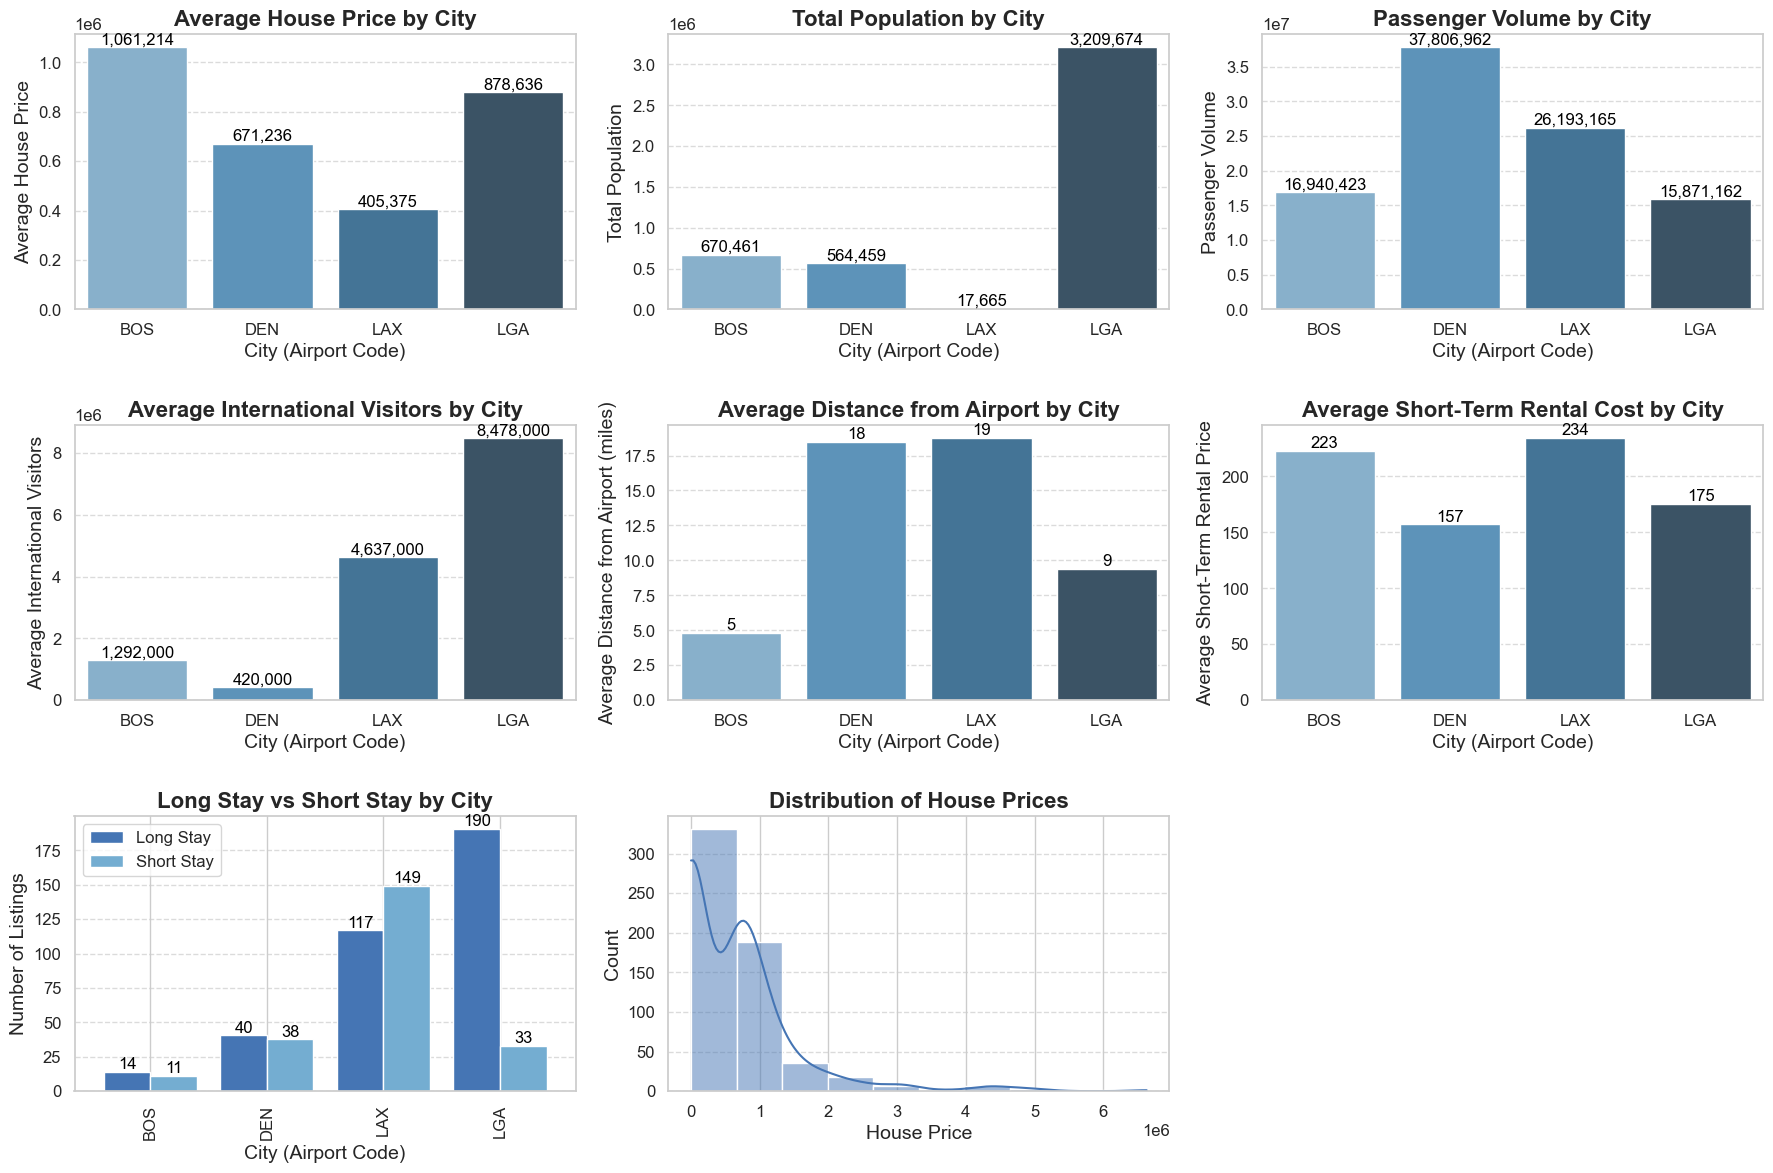

In [8]:
# Convert to numeric to plot values 
df['house_value'] = pd.to_numeric(df['house_value'], errors='coerce')
df['population'] = pd.to_numeric(df['population'], errors='coerce')
df['passengers'] = pd.to_numeric(df['passengers'], errors='coerce')
df['visitors'] = pd.to_numeric(df['visitors'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['distance_from_airport'] = pd.to_numeric(df['distance_from_airport'], errors='coerce')
df['long_term_stays'] = pd.to_numeric(df['long_term_stays'], errors='coerce')
df['short_term_stays'] = pd.to_numeric(df['short_term_stays'], errors='coerce')


agg_dict = {
    'house_value': 'mean',
    'population': 'sum',
    'passengers': 'mean',
    'visitors': 'mean',
    'price': 'mean',
    'distance_from_airport': 'mean',
    'long_term_stays': 'sum',
    'short_term_stays': 'sum'
}

# Aggregate data by city
city_agg = df.groupby('airport_code').agg(agg_dict).reset_index()
city_agg = city_agg.rename(columns={
    'house_value': 'House Price',
    'population': 'Total Population',
    'passengers': 'Passenger Volume',
    'visitors': 'International Visitors',
    'price': 'Short-Term Rentals Cost',
    'distance_from_airport': 'Airport Distance',
    'long_term_stays': 'Long-Term Stay',
    'short_term_stays': 'Short-Term Stay'
})

# Graphs for academic style reporting
# Ref: https://stackoverflow.com/questions/24547047/how-to-make-matplotlib-graphs-look-professionally-done-like-this

sns.set_theme(style="whitegrid", font_scale=1.3) 
plt.rcParams.update({'axes.titlesize': 16, 'axes.labelsize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12})


fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# Array of different plots to visualized data
plots = [
    ('House Price', 'Average House Price by City', 'Average House Price', axes[0, 0]),
    ('Total Population', 'Total Population by City', 'Total Population', axes[0, 1]),
    ('Passenger Volume', 'Passenger Volume by City', 'Passenger Volume', axes[0, 2]),
    ('International Visitors', 'Average International Visitors by City', 'Average International Visitors', axes[1, 0]),
    ('Airport Distance', 'Average Distance from Airport by City', 'Average Distance from Airport (miles)', axes[1, 1]),
    ('Short-Term Rentals Cost', 'Average Short-Term Rental Cost by City', 'Average Short-Term Rental Price', axes[1, 2])
]

for col, title, ylabel, ax in plots:
    sns.barplot(x='airport_code', y=col, data=city_agg, ax=ax, palette='Blues_d')
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('City (Airport Code)', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    for p in ax.patches:
        value = p.get_height()
        ax.annotate(f'{value:,.0f}',
                    (p.get_x() + p.get_width() / 2., value),
                    ha='center', va='bottom', fontsize=12, color='black', rotation=0)

# Long Stay vs Short Stay by City
stay_counts = city_agg[['airport_code', 'Long-Term Stay', 'Short-Term Stay']].set_index('airport_code')
ax = axes[2, 0]
stay_counts.plot(kind='bar', stacked=False, ax=ax, color=['#4575b4', '#74add1'], width=0.8)
ax.set_title('Long Stay vs Short Stay by City', fontsize=16, fontweight='bold')
ax.set_xlabel('City (Airport Code)', fontsize=14)
ax.set_ylabel('Number of Listings', fontsize=14)
ax.legend(['Long Stay', 'Short Stay'], fontsize=12)
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:,.0f}',
                             (bar.get_x() + bar.get_width() / 2., height),
                             ha='center', va='bottom', fontsize=12, color='black', rotation=0)

# Distribution of House Prices
sns.histplot(df['house_value'], bins=10, kde=True, ax=axes[2, 1], color='#4575b4')
axes[2, 1].set_title('Distribution of House Prices', fontsize=16, fontweight='bold')
axes[2, 1].set_xlabel('House Price', fontsize=14)
axes[2, 1].set_ylabel('Count', fontsize=14)
axes[2, 1].grid(True, axis='y', linestyle='--', alpha=0.7)

# Hide unused subplot
axes[2, 2].axis('off')

plt.tight_layout()
plt.savefig("images/housing_data_insights.png", dpi=300, bbox_inches='tight')
plt.show()


1. Average House Price by City: Apparently, Boston has highest house price, followed by New York indicating city-specific factors have a significant impact on housing prices and should be accounted for in both MLR and XGBoost models. 
2. Total population by City: LGA has a much higher population (~3.2M) than other cities; LAX and BOS significantly lower. Population reflects a continuous variable that may influence housing prices. It is useful in to identify demand-driven price increases.
3. Passenger Volume by City: DEN has the highest air traffic (~37M), followed by LAX. Passenger_volume can serve as a proxy for accessibility and economic activity, particularly in areas close to airports.
We can leverage this to assess economic vibrancy around the airport.
4. Average International Visitors by City: LGA and LAX attract significantly more visitors, suggesting strong tourism or global connectivity. It impacts short-term rental profitability, which in turn can indirectly affect real estate investment decisions and property pricing. This variable may enhance XGBoost model performance by capturing its nonlinear effects.
5. Average Distance from Airport by City: BOS is closest (~5 mi); LAX and DEN are further (~18–19 mi). Distance_from_airport reflects location accessibility, a key factor that directly influences a property's desirability and value. It's important for MLR to capture its linear impact, while XGBoost can detect any threshold-based or nonlinear effects it may have.
6. Average Short-Term Rental Cost by City: LAX shows the highest average rental price 234k, highlighting strong market profitability. Rental income serves as a key investment indicator and often correlates with house price growth. This variable can help MLR identify correlations and enable XGBoost to capture rent-driven price surges.
7. Long Stay vs. Short Stay by City: LAX and LGA show higher volumes of both short- and long-term stays, while BOS has minimal activity. The binary flags for long_stay and short_stay help indicate the property's primary use—whether it's residential or for investment purposes. These variables are valuable for both MLR and XGBoost, as they help the models differentiate property utility when predicting prices.
8. House Price Distribution: The data is heavily right-skewed, with most listings priced under 2M, but a few outliers reaching over 6M. Applying a log transformation may be necessary in MLR to improve normality. While XGBoost is naturally better at handling skewed distributions, it can still benefit from transformation for improved performance.

d. Hexbin plot

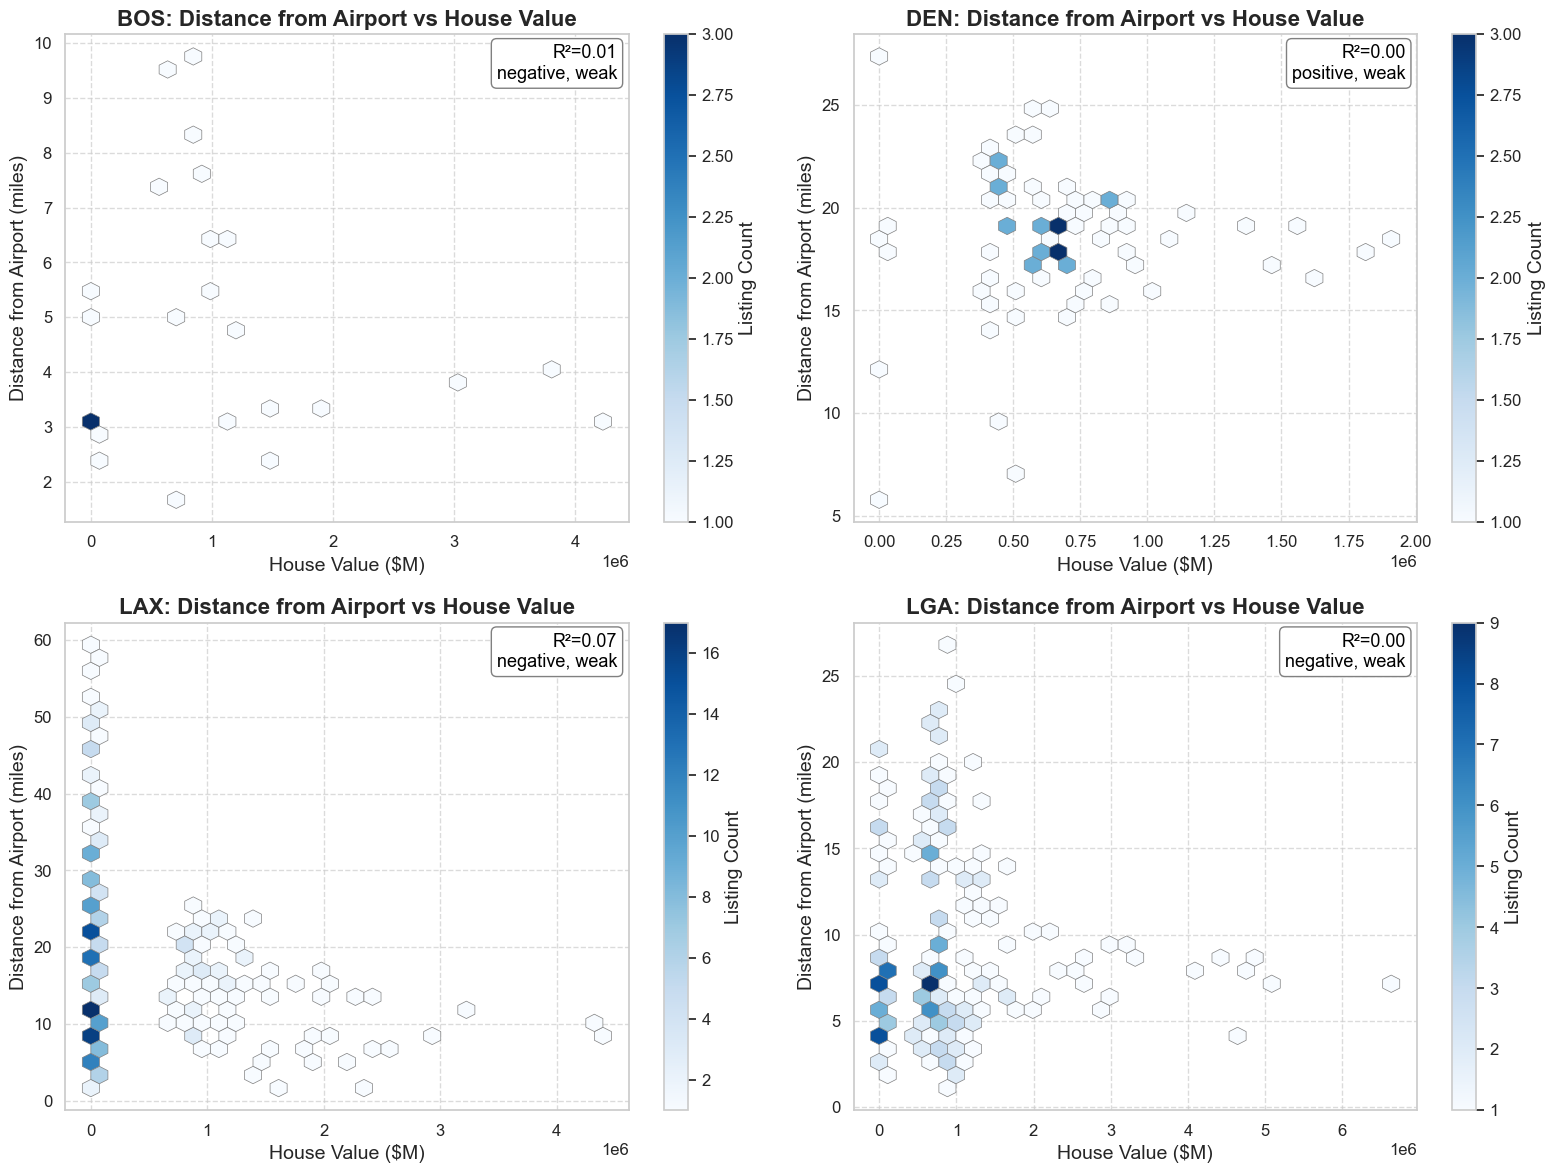

In [9]:
sns.set_theme(style="whitegrid", font_scale=1.3)
plt.rcParams.update({'axes.titlesize': 16, 'axes.labelsize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12})

cities = df['airport_code'].dropna().unique()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Ref HW2
for idx, city in enumerate(cities): 
    city_df = df[df['airport_code'] == city]
    hb = axes[idx].hexbin(
        x=city_df['house_value'],
        y=city_df['distance_from_airport'],
        gridsize=30,
        cmap='Blues',
        mincnt=1,
        linewidths=0.5,
        edgecolors='gray'
    )
    axes[idx].set_title(f"{city}: Distance from Airport vs House Value", fontsize=16, fontweight='bold')
    axes[idx].set_xlabel("House Value ($M)", fontsize=14)
    axes[idx].set_ylabel("Distance from Airport (miles)", fontsize=14)
    axes[idx].grid(True, linestyle='--', alpha=0.7)
    cb = fig.colorbar(hb, ax=axes[idx], label='Listing Count')
    cb.ax.tick_params(labelsize=12)

    # Correlation annotation
    if city_df['house_value'].nunique() > 1 and city_df['distance_from_airport'].nunique() > 1:
        slope, intercept, r_value, p_value, std_err = linregress(
            city_df['house_value'],
            city_df['distance_from_airport']
        )
        r_squared = r_value ** 2
        direction = "positive" if r_value > 0 else "negative"
        if r_squared <= 0.3:
            strength = "weak"
        elif 0.3 < r_squared < 0.7:
            strength = "moderate"
        else:
            strength = "strong"
        axes[idx].annotate(
            f"R²={r_squared:.2f}\n{direction}, {strength}",
            xy=(0.98, 0.98), xycoords='axes fraction',
            ha='right', va='top', fontsize=13, color='black',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1)
        )

# Hide unused subplots if less than 4 cities
for j in range(len(cities), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("images/hexbin_correlation.png", dpi=300, bbox_inches='tight')
plt.show()

The hexbin plots help show the relationship between house prices and distance from the airport for each city. Each colored hexagon shows how many homes are in that range—darker colors mean more listings.<br><br> 
Observation: The plot shows if house prices go up or down as the distance from the airport changes.<br>
The R² value tells how strong that relationship is, and the sign (positive or negative) shows the direction of the trend. For example, if the correlation is negative, it means that house prices go down as distance increases.<br>
If the R² is high, the relationship is strong. If it's low, the connection is weak.


e. Boxplot 

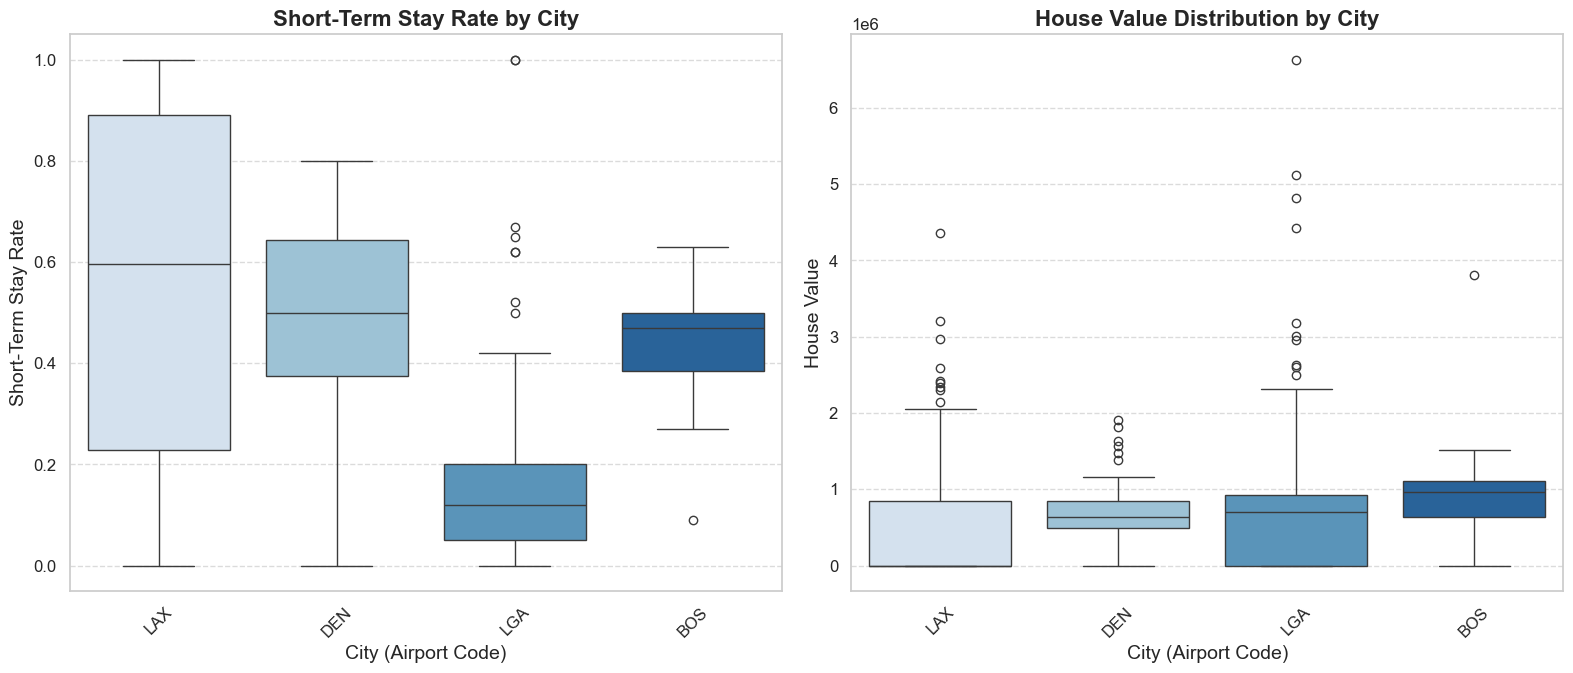

In [10]:
train_house_data['house_value'] = pd.to_numeric(train_house_data['house_value'], errors='coerce')
train_house_data['short_term_stays'] = pd.to_numeric(train_house_data['short_term_stays'], errors='coerce')

sns.set_theme(style="whitegrid", font_scale=1.3)
plt.rcParams.update({'axes.titlesize': 16, 'axes.labelsize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Box plot: Airport Code vs Short Term Stay
sns.boxplot(data=train_house_data, x='airport_code', y='short_term_stays', palette='Blues', ax=axes[0])
axes[0].set_title("Short-Term Stay Rate by City", fontsize=16, fontweight='bold')
axes[0].set_xlabel("City (Airport Code)", fontsize=14)
axes[0].set_ylabel("Short-Term Stay Rate", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.7)

# Box plot: Airport Code vs House Value
sns.boxplot(data=train_house_data, x='airport_code', y='house_value', palette='Blues', ax=axes[1])
axes[1].set_title("House Value Distribution by City", fontsize=16, fontweight='bold')
axes[1].set_xlabel("City (Airport Code)", fontsize=14)
axes[1].set_ylabel("House Value", fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("images/boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

Left Chart: Box Plot of City vs Short Term Stay shows LAX has the highest concentration and variability in short-term stays, with a median around 0.6, indicating a significant presence of short-term rental activity.
In contrast, LGA has a relatively low median, suggesting a smaller proportion of properties used for short-term rentals—potentially reflecting fewer investment-oriented listings.
DEN and BOS display a more moderate distribution, suggesting a balanced mix of both short- and long-term stays.<br>

This short-term stay rate can help us guess how a property is used—investment or residential. In cities like LAX, short-term rentals may affect housing prices, especially because of tourism demand. In a linear model (MLR), this would add a simple effect, but XGBoost can capture more complex relationships—like how short stays, airport distance, and price are connected.

Right Chart: Box Plot of Airport Code vs House Value show house price distribution (house_value) for each airport city. BOS and LGA show higher median house values than LAX and DEN. Outliers exist in all cities, with LAX and LGA having the most extreme values (up to 6.5M). LAX has a wider spread in values despite a lower median—indicating both affordable and luxury listings.

f. Correlation Heatmap

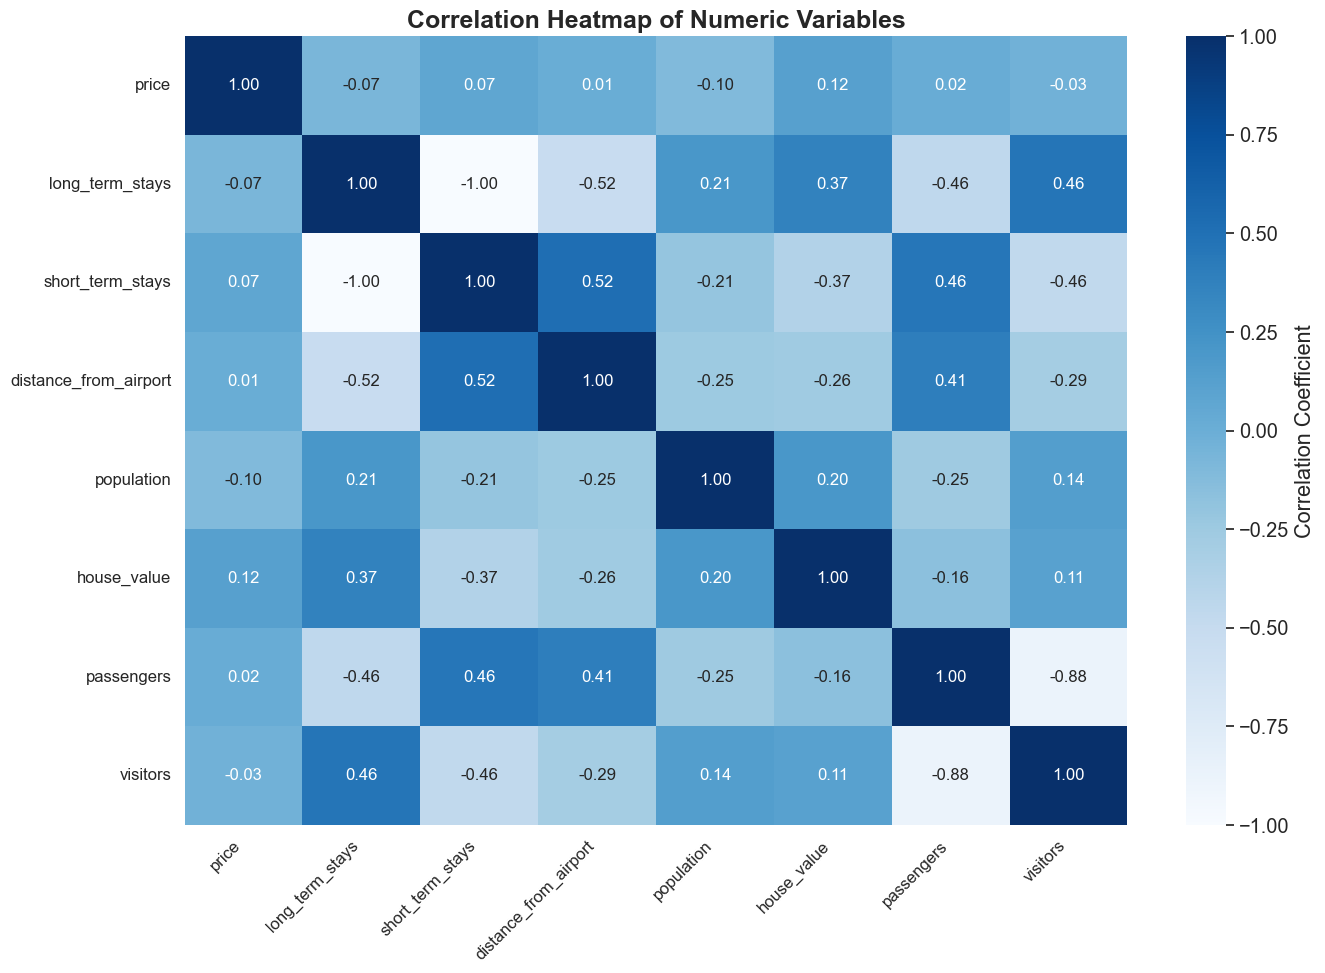

In [11]:
plt.figure(figsize=(14, 10))
corr_matrix = df.select_dtypes(include=np.number).corr()

sns.set_theme(style="whitegrid", font_scale=1.3)
heatmap = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    annot_kws={"size": 12},
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=18, fontweight='bold')
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


This heatmap visualizes pairwise correlation coefficients between variables in the dataset, ranging from -1 to 1.
long_term_stay and short_term_stays shows strong relationship with perfect -1.00 followed by passengers and visitors with -0.88 correlations and indicates multi collinearity.
long_term_stay shows moderate positive relationship with house values (0.37) suggesting long-term rentals are more common in higher value housing markets.
Variables like price, population, and passengers show weak correlation with house_value, which might be nonlinear relationships.<br><br>
Variable used for MLR are long_term_stays, distance_from_airport, and short_term_stays.<br>
Since XGB, can handle high-dimensional data better, we can use (distance_from_airport + short_term_stays) → higher house value and (airport_city + visitors) → dynamic tourism effects.
It can also capture nonlinear patterns and interactions (e.g., passengers vs. house value), even when linear correlation is weak.

g. Linearity test for,
 1. Rental Prices vs House Price


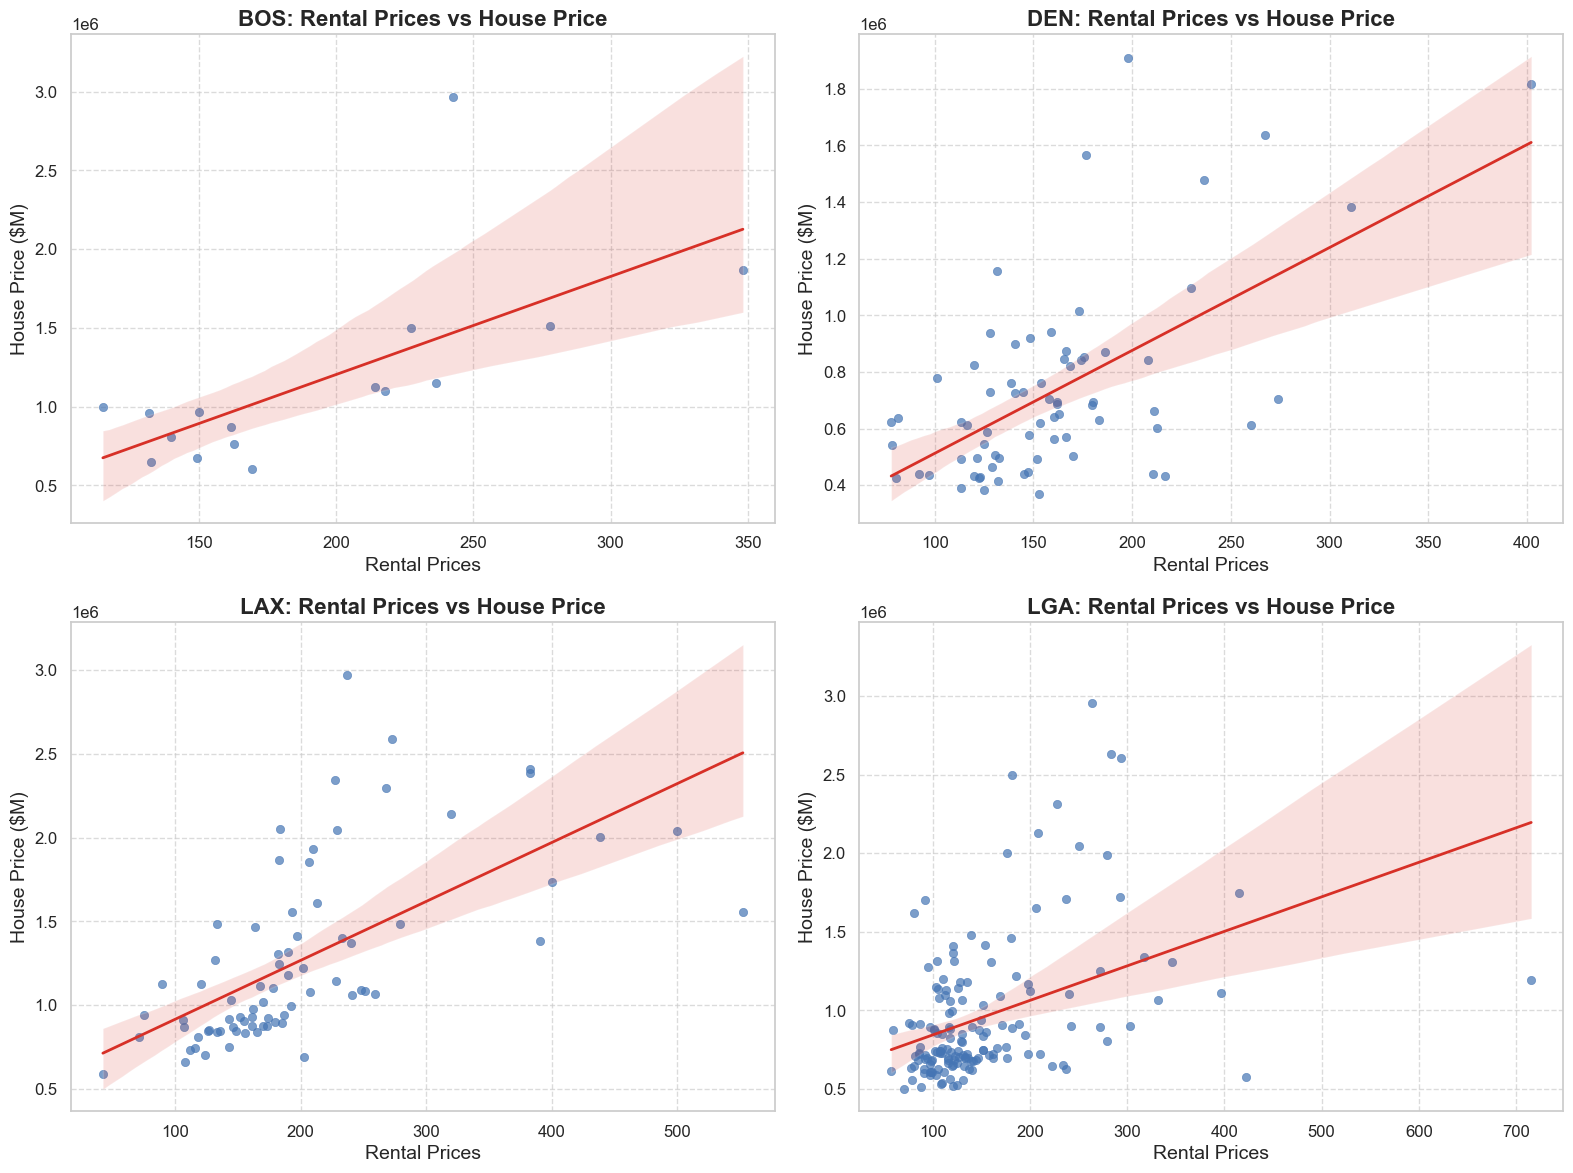

In [12]:
# Remove outliers with high prices 
df_filtered = df[(df['house_value'] > 0) & (df['house_value'] < 3_000_000)]

sns.set_theme(style="whitegrid", font_scale=1.3)
plt.rcParams.update({'axes.titlesize': 16, 'axes.labelsize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12})

cities = df_filtered['airport_code'].dropna().unique()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, city in enumerate(cities[:4]):  # Only plot up to 4 cities for 2x2 grid
    city_df = df_filtered[df_filtered['airport_code'] == city]
    sns.scatterplot(
        data=city_df,
        x='price',
        y='house_value',
        ax=axes[idx],
        alpha=0.7,
        color='#4575b4',
        edgecolor=None
    )
    # Add regression line
    sns.regplot(
        data=city_df,
        x='price',
        y='house_value',
        scatter=False,
        ax=axes[idx],
        color='#d73027',
        line_kws={'linewidth': 2}
    )
    axes[idx].set_title(f'{city}: Rental Prices vs House Price', fontsize=16, fontweight='bold')
    axes[idx].set_xlabel('Rental Prices', fontsize=14)
    axes[idx].set_ylabel('House Price ($M)', fontsize=14)
    axes[idx].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("images/linearity_rentals-Vs-housevalue.png", dpi=300, bbox_inches='tight')
plt.show()

Across all four cities, there is positive correlation between rental and housing prices. The strongest relationship are observed in Boston and Los Angeles, where it seems airbnb rates are closely tied to high property value indicating higher rental prices leads to higher house values. Hence, price can be key variable for Multiple Regression Analysis.  

1. Distance from airport vs House Prices 

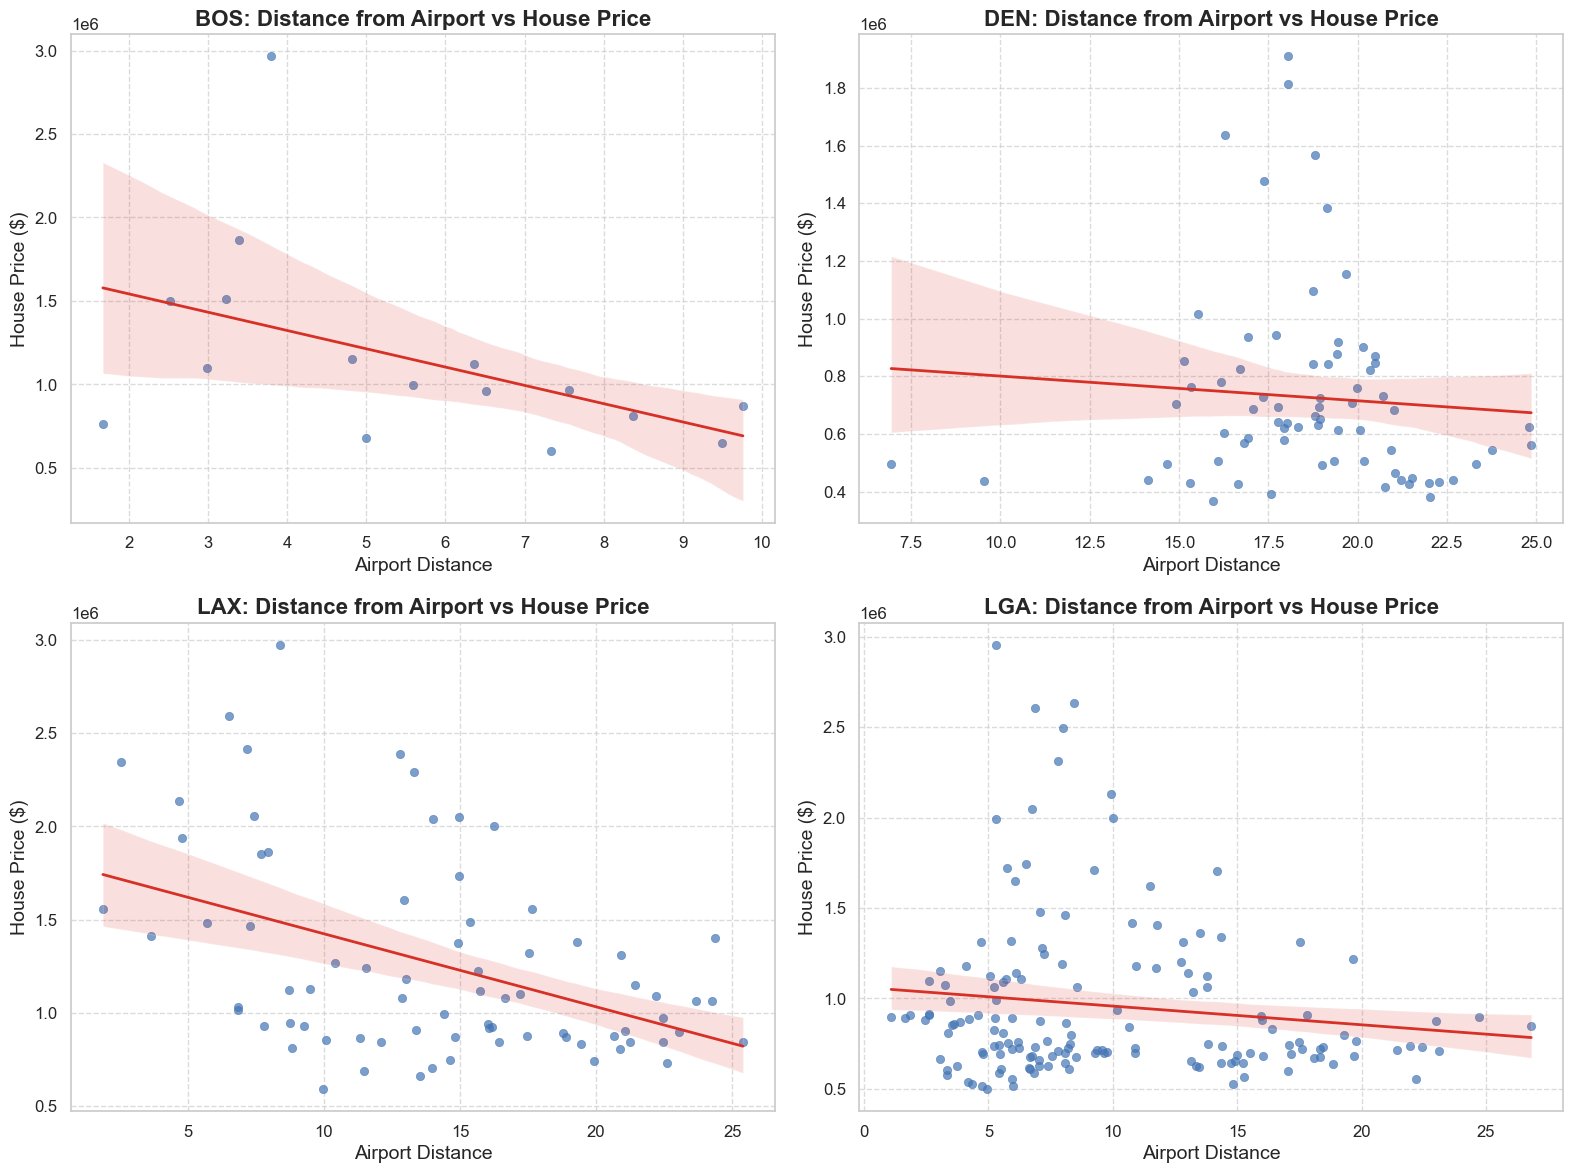

In [13]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# Filter for reasonable house prices
df_filtered = df[(df['house_value'] > 0) & (df['house_value'] < 3_000_000)]

sns.set_theme(style="whitegrid", font_scale=1.3)
plt.rcParams.update({'axes.titlesize': 16, 'axes.labelsize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12})

cities = df_filtered['airport_code'].dropna().unique()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, city in enumerate(cities[:4]):  # Only plot up to 4 cities for 2x2 grid
    city_df = df_filtered[df_filtered['airport_code'] == city]
    sns.scatterplot(
        data=city_df,
        x='distance_from_airport',
        y='house_value',
        ax=axes[idx],
        alpha=0.7,
        color="#4575b4",
        edgecolor=None
    )
    # Add regression line
    sns.regplot(
        data=city_df,
        x='distance_from_airport',
        y='house_value',
        scatter=False,
        ax=axes[idx],
        color='#d73027',
        line_kws={'linewidth': 2}
    )
    axes[idx].set_title(f'{city}: Distance from Airport vs House Price', fontsize=16, fontweight='bold')
    axes[idx].set_xlabel('Airport Distance', fontsize=14)
    axes[idx].set_ylabel('House Price ($)', fontsize=14)
    axes[idx].grid(True, linestyle='--', alpha=0.7)


plt.tight_layout()
plt.savefig("images/linearity_distance-Vs-housevalue.png")
plt.show()


Boston : Positive correlation - house price decreases as distance from the airport increases indicating proximity to airport may enhance property value. <br>
Denver : Week correlation - Minimal change in house prices with varying distance from airport.<br>
Los Angeles : Strong negative correlation - lower house prices with increase in distance from airport.<br>
New York : Moderate negative correlation - House prices decreases with distance but trend is less steep and more spread out.<br><br>
Week relationship between distance from airport and house prices are non linear and may not be a good candidate for Multiple Linear Regression but XGBoost can capture such non linearity and high dimensional data better.

# I - Multiple Linear Regression  


Based EDA and linearity test,
Chosen Predictive Variables (X): {distance_from_airport, price (rental), long_term_stays, short_term_stays, population, passengers (volume), and visitors  }
Response Variable (Y): {house_value}

# Hypothesis test 
Check if model is useful for predicting house prices using Hypothesis test

In [14]:
# import statsmodels.api as sm

# Ensure reproducibility
np.random.seed(100)

# Clean data for regression
def clean_data(X, y):
    X = sm.add_constant(X, has_constant='add')
    X = X.apply(pd.to_numeric, errors='coerce')
    y = pd.to_numeric(y, errors='coerce')
    
    df_all = pd.concat([X, y], axis=1).dropna()
    X_clean = df_all[X.columns]
    y_clean = df_all[y.name]
    return X_clean, y_clean
    

# Ref: HW4 - Forward stepwise selection for OLS

def forward_selection(X, y):
    initial_variables = X.columns.tolist()
    best_aic = float('inf')
    best_model = None
    selected_variables = ['const']
    while True:
        remaining_variables = [var for var in initial_variables if var not in selected_variables]
        new_aic = best_aic
        best_candidate = None
        for candidate in remaining_variables:
            try:
                temp_model = sm.OLS(y, X[selected_variables + [candidate]]).fit()
                if temp_model.aic < new_aic:
                    new_aic = temp_model.aic
                    best_candidate = candidate
            except Exception:
                continue
        if best_candidate:
            selected_variables.append(best_candidate)
            best_aic = new_aic
            best_model = sm.OLS(y, X[selected_variables]).fit()
        else:
            break
    return best_model

# Ref: HW2 - Hypothesis test for MLR
def hypothesis_test(model, alpha=0.05):
    null_hypothesis = "H0"
    alternative_hypothesis = "Ha"
    f_statistic = model.fvalue
    p_value = model.f_pvalue
    if p_value < alpha:
        conclusion = "Reject H0: Model is useful for predictions."
    else:
        conclusion = "Fail to reject H0: Model is not useful predictions."
    return {
        "Null": null_hypothesis,
        "Alternative": alternative_hypothesis,
        "F-statistic": f"{f_statistic:.2f}",
        "P-value": f"{p_value:.2e}",
        "Conclusion": conclusion
    }

# Manual model variables
X_manual = df[['distance_from_airport', 'price', 'long_term_stays', 'short_term_stays', 'population', 'passengers', 'visitors']]
y_manual = df['house_value']
X_manual_clean, y_manual_clean = clean_data(X_manual, y_manual)
mlr_manual = sm.OLS(y_manual_clean, X_manual_clean).fit()
print('')
#print("Manual Summary...")
#print(mlr_manual.summary())


# Full model variables
X_full = df[['price', 'availability_365', 'minimum_nights', 'long_term_stays', 'short_term_stays', 'reviews_per_month', 'number_of_reviews_ltm', 'number_of_reviews_ltm.1', 'distance_from_airport', 'population', 'neighbourhood_count', 'passengers', 'visitors']]
y_full = df['house_value']
X_full_clean, y_full_clean = clean_data(X_full, y_full)
mlr_full = sm.OLS(y_full_clean, X_full_clean).fit()
print('')
#print("Full Summary...")
#print(mlr_full.summary())


# Stepwise model
mlr_stepwise = forward_selection(X_full_clean, y_full_clean)
print('')
print("Stepwise Summary...")
print(mlr_stepwise.summary())
# Collect results for comparison

results = pd.DataFrame({
    'Model': ['Manual', 'Full', 'Stepwise'],
    'R-squared': [mlr_manual.rsquared, mlr_full.rsquared, mlr_stepwise.rsquared],
    'Adj. R-squared': [mlr_manual.rsquared_adj, mlr_full.rsquared_adj, mlr_stepwise.rsquared_adj],
    'AIC': [mlr_manual.aic, mlr_full.aic, mlr_stepwise.aic],
    'BIC': [mlr_manual.bic, mlr_full.bic, mlr_stepwise.bic]
})

# Best model based on lowest AIC
best_model_idx = results['AIC'].idxmin()
results['Best Model'] = 'No'
results.loc[best_model_idx, 'Best Model'] = 'Yes'

# Format for readability
table = results.copy()
table['R-squared'] = table['R-squared'].map('{:.4f}'.format)
table['Adj. R-squared'] = table['Adj. R-squared'].map('{:.4f}'.format)
table['AIC'] = table['AIC'].map('{:.2f}'.format)
table['BIC'] = table['BIC'].map('{:.2f}'.format)

print("\nComparison of MLR Models:")
print(tabulate.tabulate(table, headers='keys', tablefmt='github', showindex=False))

# Hypothesis test table
hypothesis_results = pd.DataFrame([
    hypothesis_test(mlr_manual),
    hypothesis_test(mlr_full),
    hypothesis_test(mlr_stepwise)
], index=['Manual', 'Full', 'Stepwise'])
print('')
print("\nTest of Overall Regression (per model):")
print("Null Hypothesis H0: All regression coefficients are equal to zero (no relationship between predictors and response)")
print("Alternative Hypothesis Ha: At least one regression coefficient is not equal to zero (there is a relationship between predictors and response)")
print("")
#print(hypothesis_results[['Null', 'Alternative', 'F-statistic', 'P-value', 'Conclusion']])

# Print as markdown table
table = hypothesis_results[['Null', 'Alternative', 'F-statistic', 'P-value', 'Conclusion']]
print(tabulate.tabulate(table, headers='keys', tablefmt='github', showindex=True))
# ...existing code...







Stepwise Summary...
                            OLS Regression Results                            
Dep. Variable:            house_value   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     24.72
Date:                Sat, 26 Apr 2025   Prob (F-statistic):           1.55e-29
Time:                        16:18:24   Log-Likelihood:                -8764.0
No. Observations:                 586   AIC:                         1.754e+04
Df Residuals:                     578   BIC:                         1.758e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const      

Since Stepwise selection resulted in the best model, above stepwise summary shows that the coefficients of the long_term_stays, availability_365, price, population, neighbourhood_count and visitors are statistically significant based on alpha 0.05 > p_value.

# Standardized Residuals 

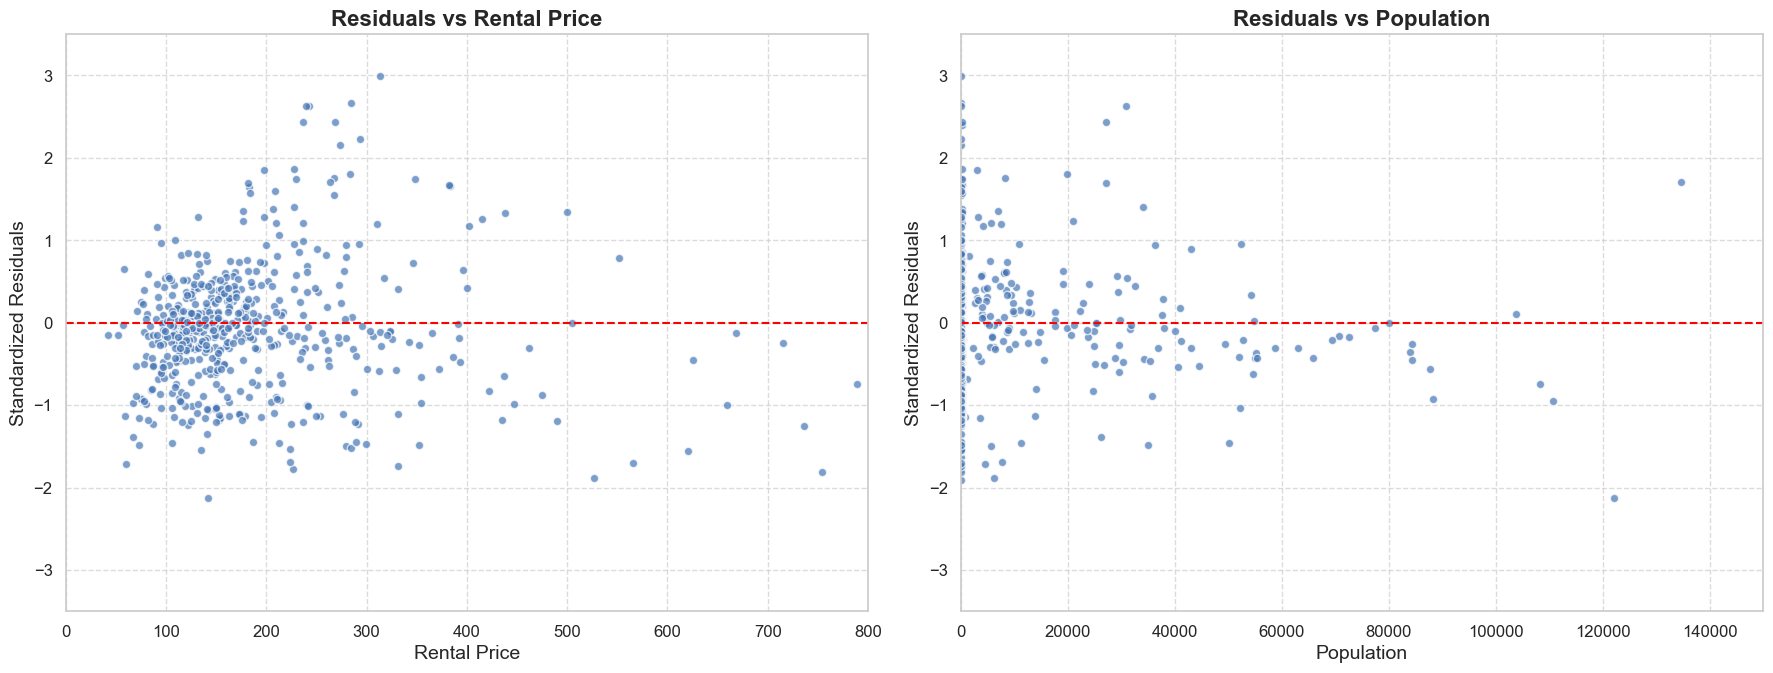

In [15]:
# 1. Standardized residuals
standardized_residuals = mlr_stepwise.get_influence().resid_studentized_internal
standardized_residuals = pd.Series(standardized_residuals, index=X_full_clean.index)

# 2. Fitted values from the model
fitted_values = mlr_stepwise.fittedvalues

# 3. Get price and population
rental_price = X_full_clean.loc[standardized_residuals.index, 'price']
population = X_full_clean.loc[standardized_residuals.index, 'population']

plt.figure(figsize=(18, 7))

# Standardized Residuals vs Rental Price
plt.subplot(1, 2, 1)
plt.scatter(rental_price, standardized_residuals, alpha=0.7, color='#4575b4', edgecolors='w')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Rental Price', fontsize=14)
plt.ylabel('Standardized Residuals', fontsize=14)
plt.title('Residuals vs Rental Price', fontsize=16, fontweight='bold')
plt.ylim(-3.5, 3.5)
plt.xlim(0, 800)
plt.grid(True, linestyle='--', alpha=0.7)

# Standardized Residuals vs Population
plt.subplot(1, 2, 2)
plt.scatter(population, standardized_residuals, alpha=0.7, color='#4575b4', edgecolors='w')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Population', fontsize=14)
plt.ylabel('Standardized Residuals', fontsize=14)
plt.title('Residuals vs Population', fontsize=16, fontweight='bold')
plt.ylim(-3.5, 3.5)
plt.xlim(0, 150000)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("images/residuals.png", dpi=300, bbox_inches='tight')
plt.show()


The residual plot shows that the residuals are randomly scattered around zero, thus showing relationship between predictors and response is linear.

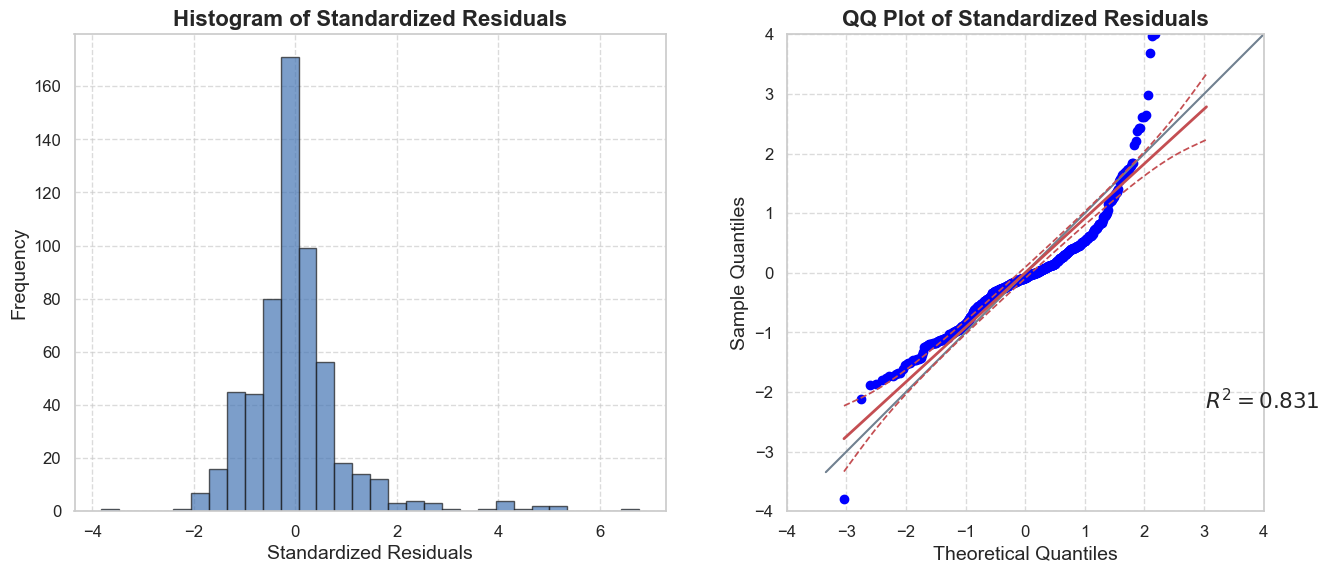

In [16]:
# import pingouin as pg 
# Create a histogram of the standardized residuals

sns.set_theme(style="whitegrid", font_scale=1.3)
plt.rcParams.update({'axes.titlesize': 16, 'axes.labelsize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12})

plt.figure(figsize=(14, 6))

# Histogram of Standardized Residuals
plt.subplot(1, 2, 1)
plt.hist(standardized_residuals, bins=30, edgecolor='k', alpha=0.7, color='#4575b4')
plt.xlabel('Standardized Residuals', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Histogram of Standardized Residuals', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)

# QQ Plot of Standardized Residuals
plt.subplot(1, 2, 2)
ax = pg.qqplot(standardized_residuals, dist='norm', confidence=.95)
ax.set_xlim([-4, +4])
ax.set_ylim([-4, +4])
ax.set_title('QQ Plot of Standardized Residuals', fontsize=16, fontweight='bold')
ax.set_xlabel('Theoretical Quantiles', fontsize=14)
ax.set_ylabel('Sample Quantiles', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("images/histQQ.png", dpi=300, bbox_inches='tight')
plt.show()

Histogram roughly show bell curve centered around zero with some right skewness and slight deviation from symmetry.
QQ Plot shows the distribution mostly normal but some deviation from normality at the end. R2 value 0.831 is closed to 1 indicating a good fit.

# Multi-collinearity and Outliers   

VIF  

In [17]:
#from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF on full model
vif_df = pd.DataFrame()
vif_df['Variable'] = X_full_clean.columns
vif_df['VIF'] = [variance_inflation_factor(X_full_clean.values, i) for i in range(X_full_clean.shape[1])]

# Threshold
r_squared = mlr_manual.rsquared
vif_threshold = max(10, 1 / (1 - r_squared))

print(vif_df)
print(f"\nVIF Threshold: {vif_threshold:.2f}")

high_vif = vif_df[vif_df['VIF'] > vif_threshold]
print("\nVariables with VIF above threshold:")
print(high_vif)


                   Variable       VIF
0                     const  0.000000
1                     price  1.064397
2          availability_365  1.073745
3            minimum_nights  2.372012
4           long_term_stays       inf
5          short_term_stays       inf
6         reviews_per_month  6.150061
7     number_of_reviews_ltm  7.384854
8   number_of_reviews_ltm.1  6.124700
9     distance_from_airport  1.700541
10               population  1.179351
11      neighbourhood_count  6.176636
12               passengers  5.253271
13                 visitors  4.962034

VIF Threshold: 10.00

Variables with VIF above threshold:
           Variable  VIF
4   long_term_stays  inf
5  short_term_stays  inf


Cook Distance for outliers.

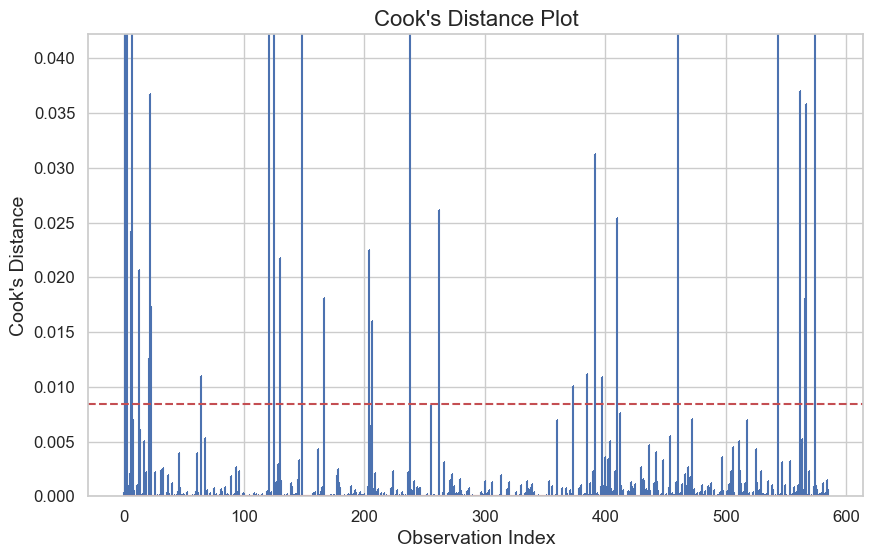

Cook's Distance Threshold: 0.0084
Number of outliers: 30
Highest 5 outlier rows from train_house_data:
     const    price  availability_365  minimum_nights  long_term_stays  \
149    1.0  1771.00             67.60            1.40             0.00   
1      1.0   243.53            197.03           24.97             0.58   
3      1.0   148.19            131.54           29.64             0.74   
580    1.0   361.49            127.16           33.13             0.95   
122    1.0  2860.55            235.76           27.83             0.67   

     short_term_stays  reviews_per_month  number_of_reviews_ltm  \
149              1.00               1.13                   3.20   
1                0.42               1.56                  10.96   
3                0.26               1.57                  10.20   
580              0.05               0.35                   1.11   
122              0.33               0.48                   1.39   

     number_of_reviews_ltm.1  distance_from_airpo

In [18]:
# Calculate Cook's distances
influence = mlr_stepwise.get_influence()
cooks_d = influence.cooks_distance[0]

# Plot Cook's distances
plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.axhline(y=4/len(train_house_data), color='r', linestyle='--')
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance Plot")

# Calculate the threshold
threshold = 4 / len(train_house_data)
plt.ylim(0, threshold * 5)
plt.show()
print(f"Cook's Distance Threshold: {threshold:.4f}")


# Identify outliers
outliers = np.where(cooks_d > threshold)[0]
num_outliers = len(outliers)
print(f"Number of outliers: {num_outliers}")

# Output the highest 5 outlier rows from train_house_data
highest_outliers = np.argsort(cooks_d)[-5:]
print("Highest 5 outlier rows from train_house_data:")
print(X_full_clean.iloc[highest_outliers])


# Prediction 

1. Manual Model - Variables Selection based on Exploratory Data Analysis. 
Predictive Variables (X): {distance_from_airport, price , population, passengers , and visitors  }
2. Full Model - Predictive Variables (X): {'price', 'availability_365', 'minimum_nights', 'reviews_per_month', 'number_of_reviews_ltm', 'number_of_reviews_ltm.1', 'distance_from_airport', 'population', 'neighbourhood_count', 'passengers', 'visitors'}
3. Stepwise Model - Predictive Variables (X): {'price', 'availability_365', 'population', 'neighbourhood_count', 'passengers', 'visitors'}
Note: Removed long_term_stays and short_term_stays from variable selections since these variable has high collinearity and is rejected based in VIF threshold analysis.

In [19]:
# from sklearn.metrics import mean_squared_error

# Ensure all columns in test_house_data are numeric
numeric_cols = ['house_value', 'price', 'availability_365', 'minimum_nights', 'reviews_per_month',
                'number_of_reviews_ltm', 'number_of_reviews_ltm.1', 'long_term_stays', 'short_term_stays',
                'distance_from_airport', 'population', 'neighbourhood_count', 'passengers', 'visitors']

test_house_data[numeric_cols] = test_house_data[numeric_cols].apply(pd.to_numeric, errors='coerce')


# 1. Manual Model Prediction
X_manual_pred = test_house_data[X_manual_clean.columns.drop('const')].fillna(0)
X_manual_pred = sm.add_constant(X_manual_pred, has_constant='add')
X_manual_pred = X_manual_pred.apply(pd.to_numeric, errors='coerce')
y_manual_pred = mlr_manual.predict(X_manual_pred)

# 2. Full Model Prediction
X_full_pred = test_house_data[X_full_clean.columns.drop('const')].fillna(0)
X_full_pred = sm.add_constant(X_full_pred, has_constant='add')
X_full_pred = X_full_pred.apply(pd.to_numeric, errors='coerce')
y_full_pred = mlr_full.predict(X_full_pred)

# 3. Stepwise Model Prediction
stepwise_features = [var for var in mlr_stepwise.model.exog_names if var != 'const']
X_stepwise_pred = test_house_data[stepwise_features].fillna(0)
X_stepwise_pred = sm.add_constant(X_stepwise_pred, has_constant='add')
X_stepwise_pred = X_stepwise_pred.apply(pd.to_numeric, errors='coerce')
y_stepwise_pred = mlr_stepwise.predict(X_stepwise_pred)

# Actual values
y_actual = test_house_data['house_value'].fillna(0)

# Calculate MSPE and RMSE
mlr_mspe_manual = mean_squared_error(y_actual, y_manual_pred)
mlr_mspe_full = mean_squared_error(y_actual, y_full_pred)
mlr_mspe_stepwise = mean_squared_error(y_actual, y_stepwise_pred)

mlr_rmse_manual = np.sqrt(mlr_mspe_manual)
mlr_rmse_full = np.sqrt(mlr_mspe_full)
mlr_rmse_stepwise = np.sqrt(mlr_mspe_stepwise)

# Calculate R2 and Adjusted R2 for test set
def adj_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

n = len(y_actual)
k_manual = len(X_manual_pred.columns)
k_full = len(X_full_pred.columns)
k_stepwise = len(X_stepwise_pred.columns)

# Get coefficient error metrics
mlr_r2_manual = np.corrcoef(y_actual, y_manual_pred)[0, 1] ** 2
mlr_r2_full = np.corrcoef(y_actual, y_full_pred)[0, 1] ** 2
mlr_r2_stepwise = np.corrcoef(y_actual, y_stepwise_pred)[0, 1] ** 2

mlr_adj_r2_manual = adj_r2(mlr_r2_manual, n, k_manual)
mlr_adj_r2_full = adj_r2(mlr_r2_full, n, k_full)
mlr_adj_r2_stepwise = adj_r2(mlr_r2_stepwise, n, k_stepwise)

# Find best model having lowest MSPE
mspe_list = [mlr_mspe_manual, mlr_mspe_full, mlr_mspe_stepwise]
best_idx = np.argmin(mspe_list)
best_model_flags = ['No', 'No', 'No']
best_model_flags[best_idx] = 'Yes'

# Tabular summary
results_df = pd.DataFrame({
    'Model': ['Manual', 'Full', 'Stepwise'],
    'MSPE': [mlr_mspe_manual, mlr_mspe_full, mlr_mspe_stepwise],
    'RMSE': [mlr_rmse_manual, mlr_rmse_full, mlr_rmse_stepwise],
    'R2': [mlr_r2_manual, mlr_r2_full, mlr_r2_stepwise],
    'Adjusted R2': [mlr_adj_r2_manual, mlr_adj_r2_full, mlr_adj_r2_stepwise],
    'Best Model': best_model_flags
})

table = results_df.copy()
table['MSPE'] = table['MSPE'].map('{:,.2f}'.format)
table['RMSE'] = table['RMSE'].map('{:,.2f}'.format)
table['R2'] = table['R2'].map('{:.4f}'.format)
table['Adjusted R2'] = table['Adjusted R2'].map('{:.4f}'.format)

print("Predictive Model Comparison \n")
print(tabulate.tabulate(table, headers='keys', tablefmt='github', showindex=False))



Predictive Model Comparison 

| Model    | MSPE               | RMSE       |     R2 |   Adjusted R2 | Best Model   |
|----------|--------------------|------------|--------|---------------|--------------|
| Manual   | 856,685,969,725.11 | 925,573.32 | 0.2054 |        0.1471 | No           |
| Full     | 832,448,016,793.93 | 912,385.89 | 0.2227 |        0.117  | Yes          |
| Stepwise | 838,493,136,066.09 | 915,692.71 | 0.2167 |        0.1592 | No           |


Results after removing high multi collinearity variables long_term_stays and short_term_stays, the full model now performs best on the given test, as indicated by the lowest MSPE and RMSE. 
Other 2 models have relatively low R-Squared, suggesting limited predictive power, but the Full model is still the best indicating removing high collinearity variables improved model stability and generalization. 

# II - XGBoost

Use XGBoost on full model which is the best model from MLR. 

In [20]:
xgb_variables = ['price', 'availability_365', 'minimum_nights', 'reviews_per_month',
                'number_of_reviews_ltm', 'number_of_reviews_ltm.1', 'long_term_stays','short_term_stays', 'distance_from_airport',
                'population', 'neighbourhood_count', 'passengers', 'visitors']

# Prepare training and test data
X_train = train_house_data[xgb_variables].apply(pd.to_numeric, errors='coerce')
y_train = train_house_data['house_value'].apply(pd.to_numeric, errors='coerce')
X_test = test_house_data[xgb_variables].apply(pd.to_numeric, errors='coerce')
y_test = test_house_data['house_value'].apply(pd.to_numeric, errors='coerce')

# Train XGBoost regressor
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=100, n_estimators=100)
xgb_reg.fit(X_train, y_train)

# Predict
y_pred = xgb_reg.predict(X_test)

# Metrics
xgb_mspe = mean_squared_error(y_test, y_pred)
xgb_rmse = np.sqrt(xgb_mspe)
xgb_r2 = r2_score(y_test, y_pred)
xgb_adj_r2 = 1 - (1 - xgb_r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print("XGBoost Regression Results:")
print(f"MSPE: {xgb_mspe:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"R2: {xgb_r2:.4f}")
print(f"Adjusted R2: {xgb_adj_r2:.4f}")

XGBoost Regression Results:
MSPE: 694365051065.0544
RMSE: 833285.6959
R2: 0.3423
Adjusted R2: 0.2601


# Model Comparision

Predictive Model Comparison

| Model      | MSPE               | RMSE       |     R2 |   Adjusted R2 | Best Model   |
|------------|--------------------|------------|--------|---------------|--------------|
| MLR (Full) | 832,448,016,793.93 | 912,385.89 | 0.2227 |        0.117  | No           |
| XGBoost    | 694,365,051,065.05 | 833,285.70 | 0.3423 |        0.2601 | Yes          |


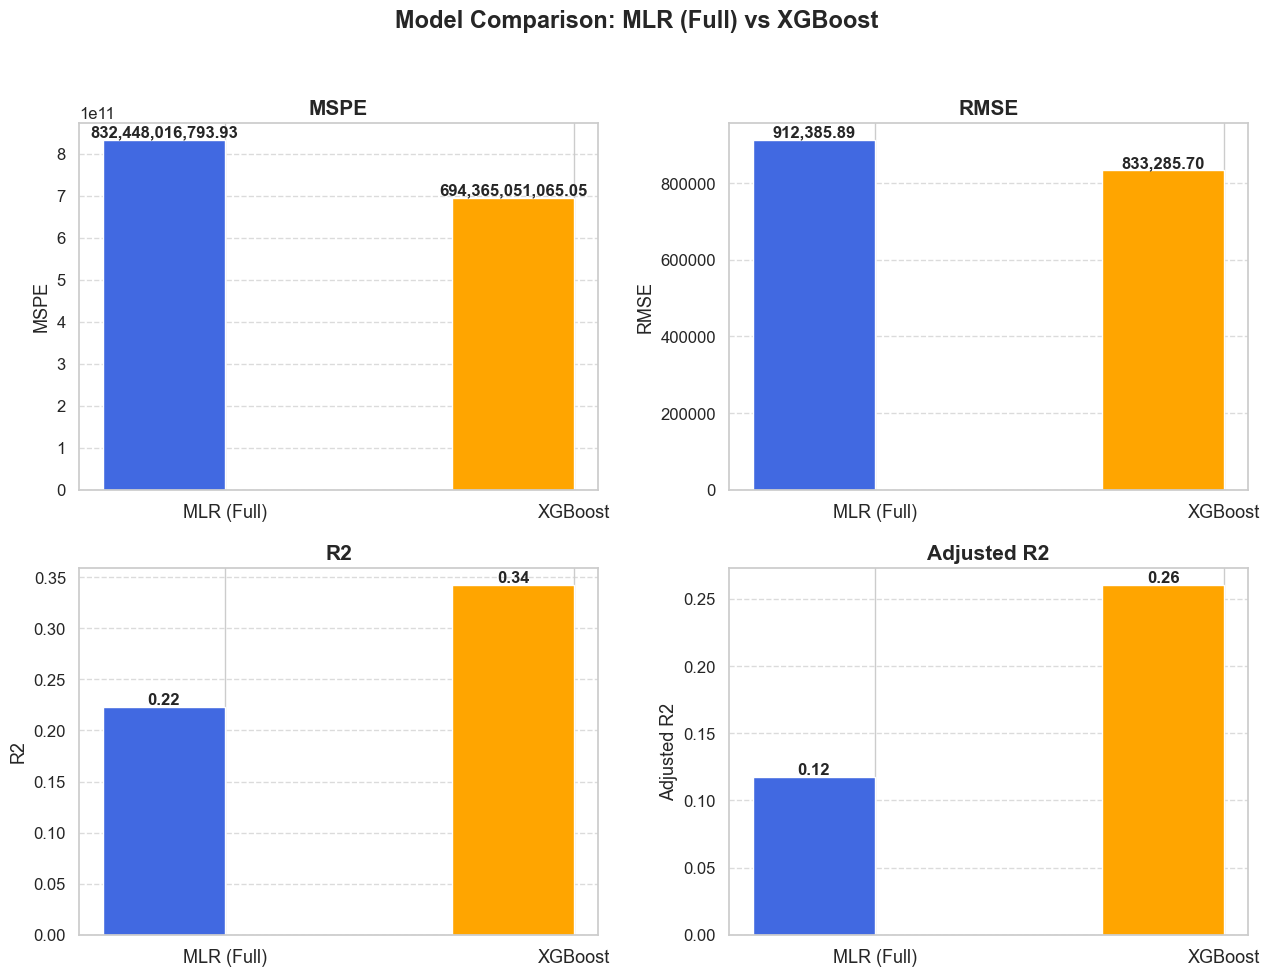

In [21]:

coeff_metrics = ['MSPE', 'RMSE', 'R2', 'Adjusted R2']
mlr_values = [mlr_mspe_full, mlr_rmse_full, mlr_r2_full, mlr_adj_r2_full]
xgb_values = [xgb_mspe, xgb_rmse, xgb_r2, xgb_adj_r2]
models = ['MLR (Full)', 'XGBoost']
bar_colors = ['royalblue', 'orange']

# Compare only MLR (Full) and XGBoost
mspe_list = [mlr_mspe_full, xgb_mspe]
best_idx = np.argmin(mspe_list)
best_model_flags = ['No', 'No']
best_model_flags[best_idx] = 'Yes'

results_df = pd.DataFrame({
    'Model': models,
    'MSPE': [mlr_mspe_full, xgb_mspe],
    'RMSE': [mlr_rmse_full, xgb_rmse],
    'R2': [mlr_r2_full, xgb_r2],
    'Adjusted R2': [mlr_adj_r2_full, xgb_adj_r2],
    'Best Model': best_model_flags
})

# Format for readability
table = results_df.copy()
table['MSPE'] = table['MSPE'].map('{:,.2f}'.format)
table['RMSE'] = table['RMSE'].map('{:,.2f}'.format)
table['R2'] = table['R2'].map('{:.4f}'.format)
table['Adjusted R2'] = table['Adjusted R2'].map('{:.4f}'.format)

print("Predictive Model Comparison\n")
print(tabulate.tabulate(table, headers='keys', tablefmt='github', showindex=False))

# Academic-style bar plots with blue shades
plt.rcParams.update({'axes.titlesize': 15, 'axes.labelsize': 13, 'xtick.labelsize': 12, 'ytick.labelsize': 12})
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

bar_width = 0.35
x = np.arange(len(models))

for i, metric in enumerate(coeff_metrics):
    bar_positions = x - bar_width/2
    axes[i].bar(bar_positions, [mlr_values[i], xgb_values[i]], width=bar_width, color=bar_colors)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(models, fontsize=13)
    axes[i].set_title(metric, fontsize=15, fontweight='bold')
    axes[i].set_ylabel(metric, fontsize=13)
    axes[i].grid(True, axis='y', linestyle='--', alpha=0.7)
    for idx, value in enumerate([mlr_values[i], xgb_values[i]]):
        axes[i].annotate(f'{value:,.2f}', (bar_positions[idx], value), 
                         ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.suptitle('Model Comparison: MLR (Full) vs XGBoost', fontsize=17, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("images/mlr-xgb-comparison.png", dpi=300, bbox_inches='tight')
plt.show()

XGBoost outperformed full multiple linear models. The higher R-Squared and lower error metrics explains more variance in house prices and makes more accurate predictions. Note we included high multi-collinearity variables long_term_stays and short_term_stays. These metrics and previous analysis suggest that our data set is not completely linear but has multi-collinearity and high dimensional patterns. Since XGBoost is robust to outliers and its ability to model complex pattern leads to better predictive performance. 

# Models Performance Trend MLR vs XGB
Visualized the trend of actual and predicted values across the sorted samples by actual house value for each city. Sorting the actual house prices makes it easier to see how well the predicted values from MLR and XGBoost follow the real trend. This helps compare how both models perform across different price ranges.

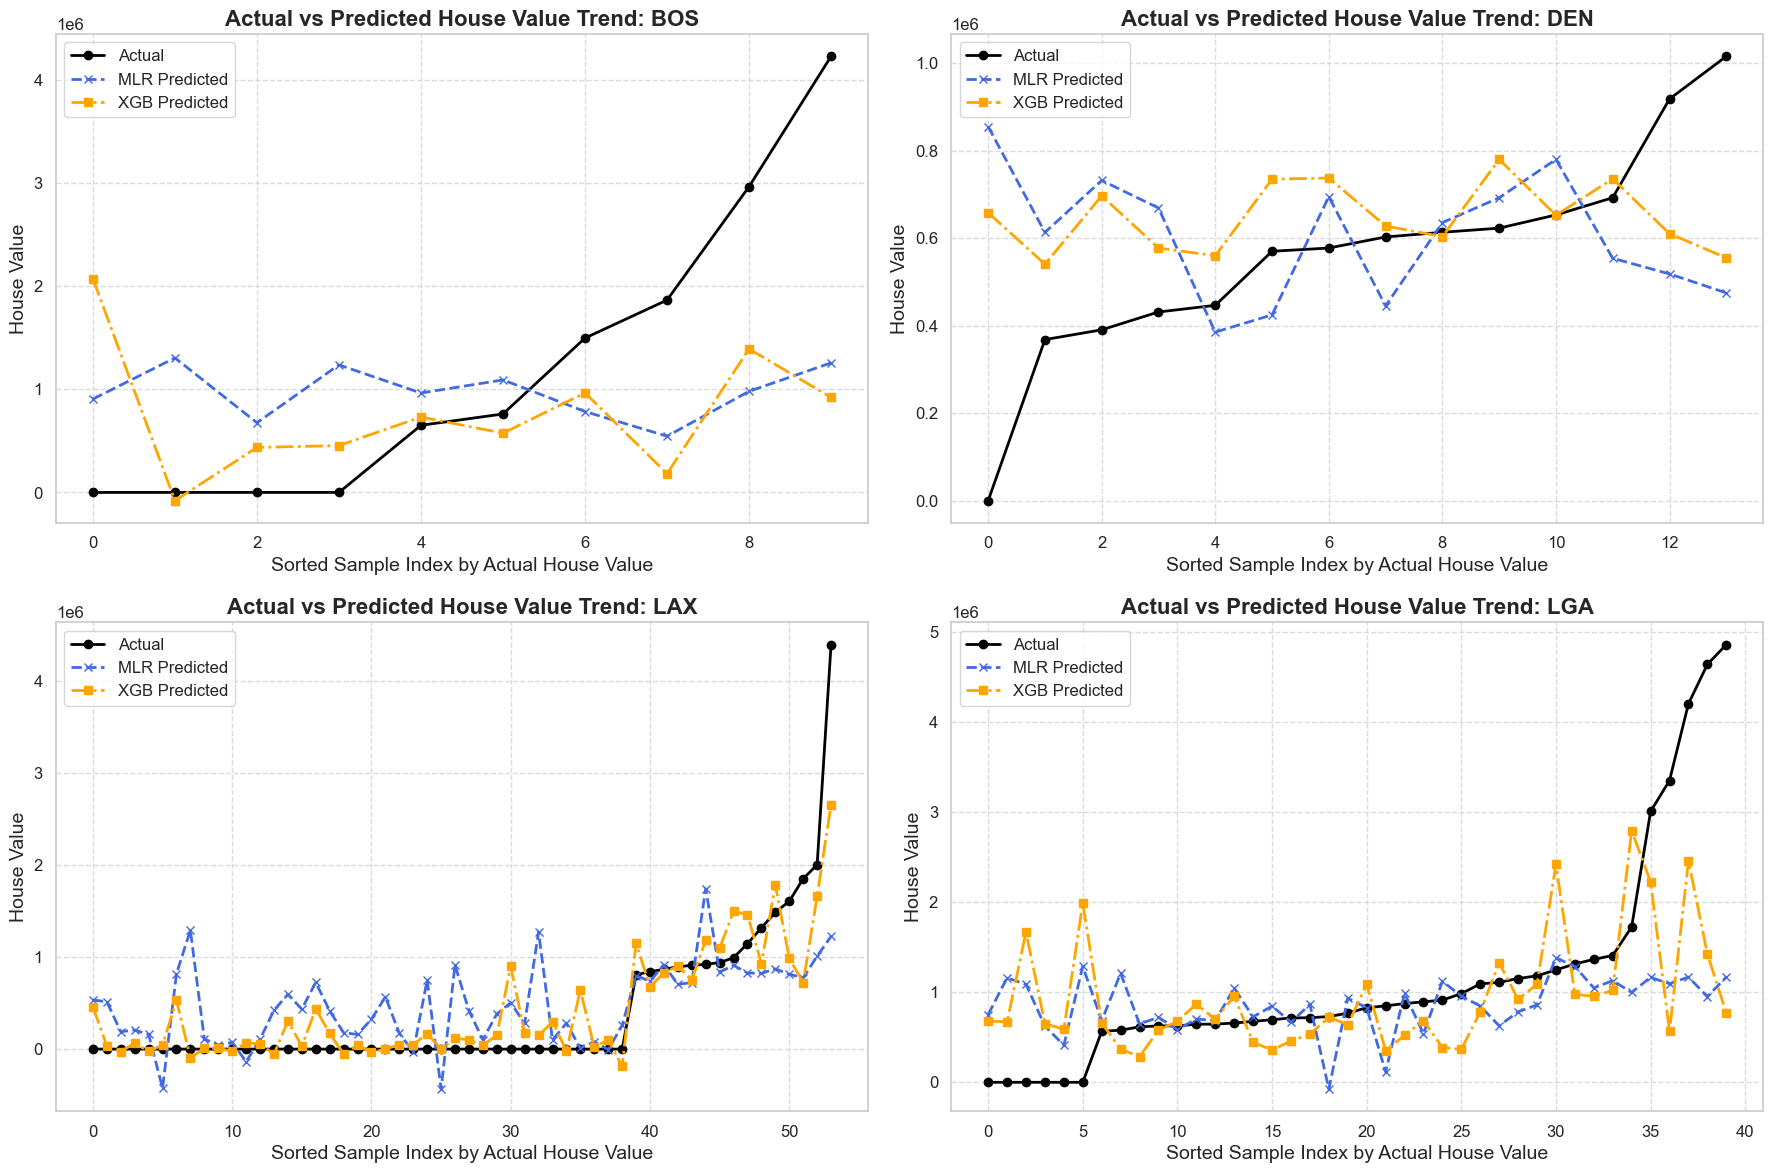

In [22]:

test_house_data['MLR_Pred'] = y_full_pred
test_house_data['XGB_Pred'] = y_pred

plot_df = test_house_data[['airport_code', 'house_value', 'MLR_Pred', 'XGB_Pred']].dropna()
cities = plot_df['airport_code'].unique()

sns.set_theme(style="whitegrid", font_scale=1.3)
plt.rcParams.update({'axes.titlesize': 16, 'axes.labelsize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12})

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, city in enumerate(cities):
    city_df = plot_df[plot_df['airport_code'] == city].sort_values('house_value')
    ax = axes[idx]
    ax.plot(city_df['house_value'].values, label='Actual', color='black', marker='o', linestyle='-', linewidth=2)
    ax.plot(city_df['MLR_Pred'].values, label='MLR Predicted', color='royalblue', marker='x', linestyle='--', linewidth=2)  
    ax.plot(city_df['XGB_Pred'].values, label='XGB Predicted', color='orange', marker='s', linestyle='-.', linewidth=2) 
    ax.set_title(f'Actual vs Predicted House Value Trend: {city}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Sorted Sample Index by Actual House Value', fontsize=14)
    ax.set_ylabel('House Value', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("images/mlr-xgb-performancetrend.png", dpi=300, bbox_inches='tight')
plt.show()

In the above graph, the black line represents the actual house values for each city.<br>
The blue dashed line shows predictions from the Multiple Linear Regression (MLR) model.<br>
The orange dash-dot line shows predictions from the XGBoost model.<br>
<br>
Observations: XGBoost generally tracks the actual values more closely than MLR, especially in cities where house prices vary more.<br>
MLR predictions look smoother but tend to miss the ups and downs, especially when there are outliers or unusual values—it seems to underfit in those cases.
<br>Both models seem to struggle a bit with properties at the extreme ends (very high or very low prices), likely due to outliers or complex relationships that MLR doesn’t capture well.<br>
XGBoost, on the other hand, does a better job adjusting to non-linear trends and outliers—it stays closer to the actual values more often.

# K-fold Cross Validation
We will be using K-fold cross validation to evaluate the predictive performance of MLR and XGB by splitting data into multiple folds and training/testing the models on different subsets.

In [23]:
variables = ['price', 'availability_365', 'minimum_nights', 'reviews_per_month',
            'number_of_reviews_ltm', 'number_of_reviews_ltm.1', 'long_term_stays', 'short_term_stays',
            'distance_from_airport', 'population', 'neighbourhood_count', 'passengers', 'visitors']

X = df[variables].apply(pd.to_numeric, errors='coerce').dropna()
y = df.loc[X.index, 'house_value'].apply(pd.to_numeric, errors='coerce')

kf = KFold(n_splits=5, shuffle=True, random_state=100)

# MLR Cross-validation
mlr = LinearRegression()
mlr_cv_scores = cross_val_score(mlr, X, y, cv=kf, scoring='neg_mean_squared_error')
mlr_cv_rmse = np.sqrt(-mlr_cv_scores)

# XGBoost Cross-validation
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=100, n_estimators=100)
xgb_cv_scores = cross_val_score(xgb_reg, X, y, cv=kf, scoring='neg_mean_squared_error')
xgb_cv_rmse = np.sqrt(-xgb_cv_scores)

# Prepare results table
results = pd.DataFrame({
    'Model': ['MLR'] * len(mlr_cv_rmse) + ['XGBoost'] * len(xgb_cv_rmse),
    'Fold': list(range(1, 6)) * 2,
    'RMSE': np.concatenate([mlr_cv_rmse, xgb_cv_rmse])
})

# Print mean and std in tabular format
summary = pd.DataFrame({
    'Model': ['MLR', 'XGBoost'],
    'Mean RMSE': [mlr_cv_rmse.mean(), xgb_cv_rmse.mean()],
    'Std RMSE': [mlr_cv_rmse.std(), xgb_cv_rmse.std()]
})

print("Cross-Validation RMSE by Fold\n")
print(tabulate.tabulate(results.pivot(index='Fold', columns='Model', values='RMSE').round(2), headers='keys', tablefmt='github'))
print("\nCross-Validation RMSE Summary\n")
print(tabulate.tabulate(summary, headers='keys', tablefmt='github', showindex=False))


Cross-Validation RMSE by Fold

|   Fold |    MLR |   XGBoost |
|--------|--------|-----------|
|      1 | 751509 |    643404 |
|      2 | 787014 |    646086 |
|      3 | 916703 |    788448 |
|      4 | 738977 |    517412 |
|      5 | 694670 |    507229 |

Cross-Validation RMSE Summary

| Model   |   Mean RMSE |   Std RMSE |
|---------|-------------|------------|
| MLR     |      777775 |    75482.3 |
| XGBoost |      620516 |   102804   |


CV results shows XGBoost has lower RMSE than MLR in every fold. Since the average RMSE for XGBoost (620516) is better (lower) than for MLR (777775), indicating XGBoost made more accurate prediction overall.   

The scatter plots comparing actual and predicted house prices depicts a visual of model performance across cities.<br>
<br>

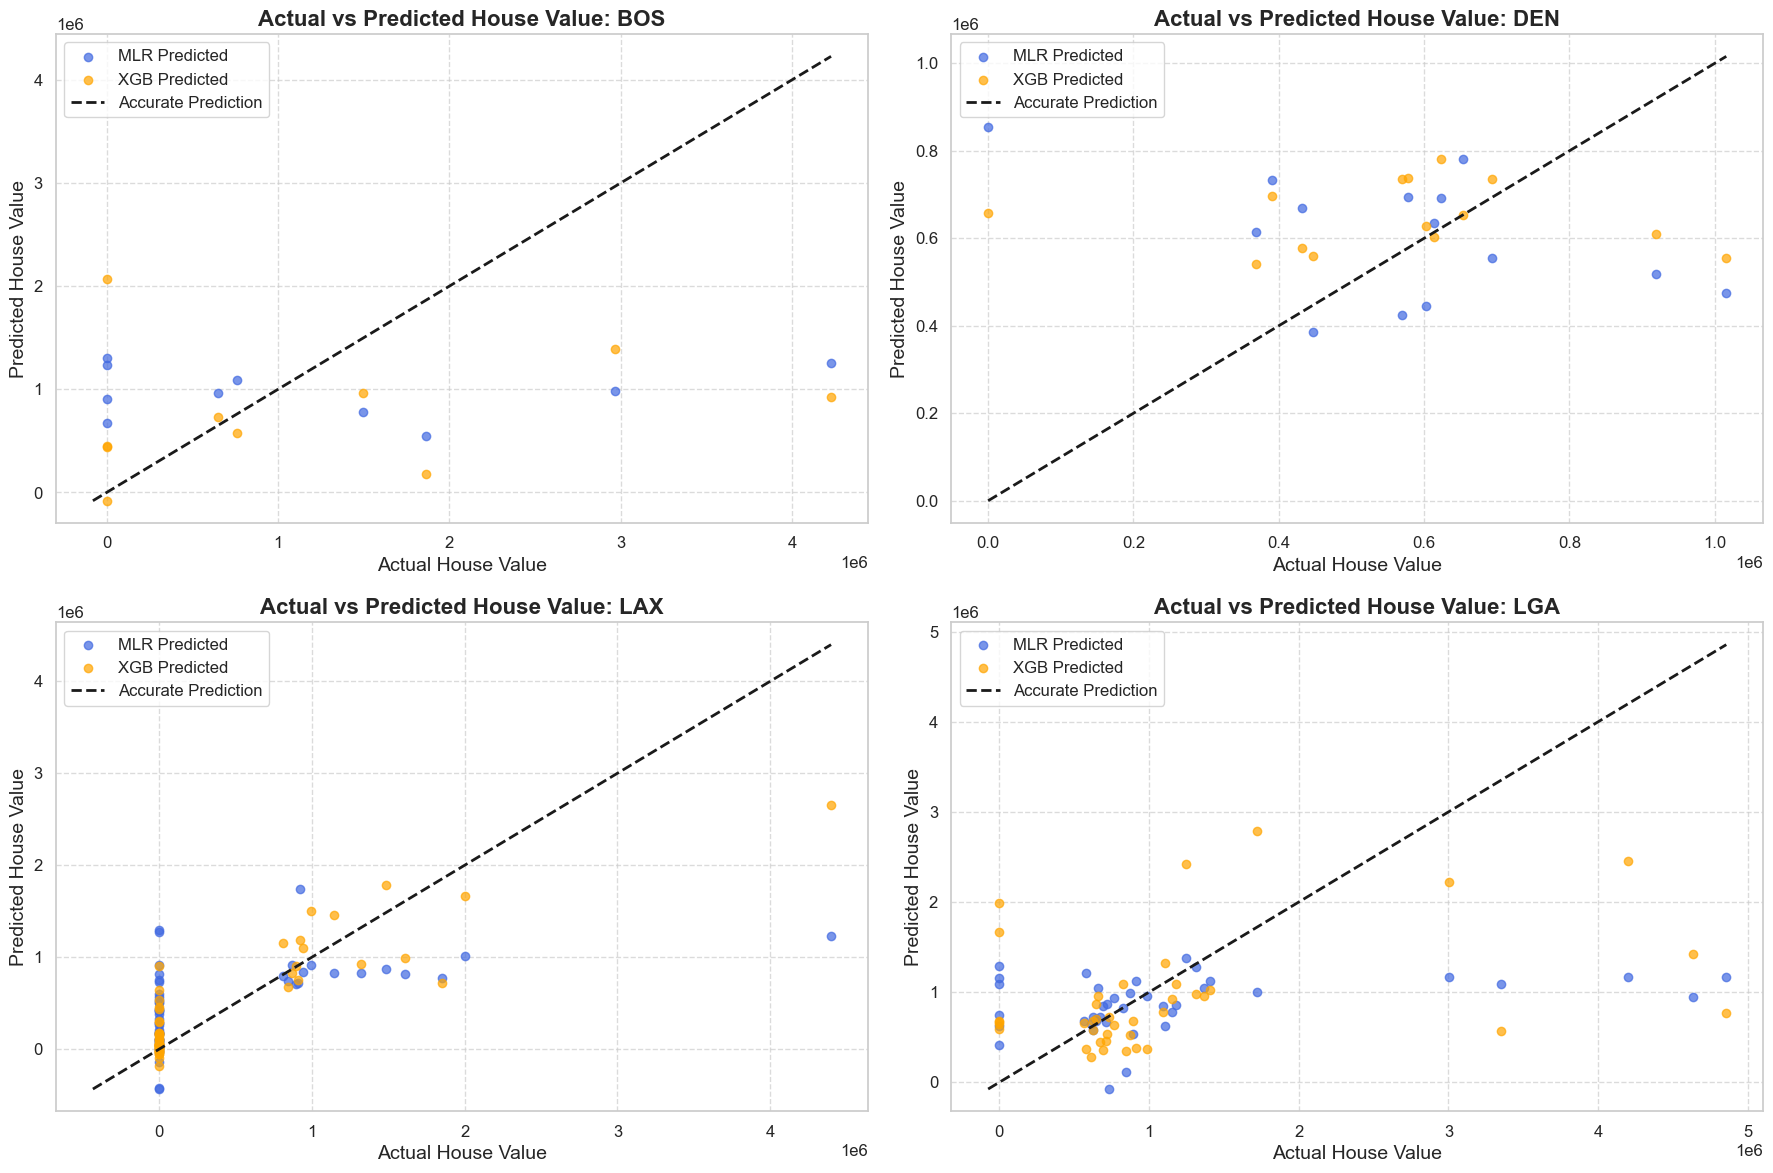

In [24]:

plot_df = test_house_data[['airport_code', 'house_value', 'MLR_Pred', 'XGB_Pred']].dropna()
cities = plot_df['airport_code'].unique()

sns.set_theme(style="whitegrid", font_scale=1.3)
plt.rcParams.update({'axes.titlesize': 16, 'axes.labelsize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12})

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, city in enumerate(cities):
    city_df = plot_df[plot_df['airport_code'] == city]
    ax = axes[idx]
    # Scatter for MLR (light yellow)
    ax.scatter(city_df['house_value'], city_df['MLR_Pred'], color='royalblue', alpha=0.7, label='MLR Predicted')
    # Scatter for XGB (dark blue)
    ax.scatter(city_df['house_value'], city_df['XGB_Pred'], color='orange', alpha=0.7, label='XGB Predicted')
    # Diagonal line for perfect prediction
    min_val = min(city_df['house_value'].min(), city_df['MLR_Pred'].min(), city_df['XGB_Pred'].min())
    max_val = max(city_df['house_value'].max(), city_df['MLR_Pred'].max(), city_df['XGB_Pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Accurate Prediction')
    ax.set_title(f'Actual vs Predicted House Value: {city}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Actual House Value', fontsize=14)
    ax.set_ylabel('Predicted House Value', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)

# Hide unused subplots if any
for j in range(len(cities), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("images/mlr-xgb-actual-Vs-prediction.png", dpi=300, bbox_inches='tight')
plt.show()


Points near the diagonal = accurate predictions<br>
Above the line = overprediction,<br> 
Below = underprediction<br>
<br>
MLR performs better in cities with linear relationships, while XGBoost excels in capturing non-linear patterns and complexities. Both models show larger errors at extreme price ranges, indicating outliers or modeling limitations
Summary:
Both MLR and XGBoost generally follow the trend in house values, but their effectiveness varies by city and price range. XGBoost handles non-linearity and outliers better, while MLR is effective with linear patterns. Further feature engineering, outlier treatment, and tuning can improve results.

# Conclusion 


This analysis combined multiple datasets and advanced modeling to predict house values across major U.S. cities. Multiple Linear Regression (MLR) served as a strong, interpretable baseline, but XGBoost consistently outperformed MLR, showing lower RMSE and higher R² scores in both cross-validation and other test results.

After performing diagnostic checks it showed that removing highly correlated variables improved model stability, and visualizations highlighted that XGBoost captured complex patterns , Multicollinearity and outliers more effectively. Overall, XGBoost is recommended for better predictive performance, while MLR remains useful for explaining linear relationships and maintaining model transparency.